# Notebook 1 : Building Schema & Data Cleaning

Written By Kelly-Marie Yokuda for the BrainStation Capstone Project "Professor Power Index"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import seaborn as sns
import os

# Project Introduction

To assist early career researchers in establishing their prestige, we demonstrate how machine learning can help early career researchers identify potential co-authors within their network whose added authorship could increase the likelihood of their research being published in highly-cited scientific journals. Specifically, we show that a classification model trained on a database of publications authored by prestigious researchers can successfully classify publications into tiers of scientific journals using co-author metrics alone. 

# Notebook Introduction

In this notebook, we perform preliminary data cleaning on the raw data sets pulled from Google Scholar using the [Publish or Perish]( https://harzing.com/resources/publish-or-perish) web scrapping software and publication metric hosting online database [Scimago Journal & Country Rank](https://www.scimagojr.com/journalrank.php). 

Our goal is to create a relational database of data tables that contain minimal null entries, duplicated rows and uniform formatting of features. To start, the database will include three tables:

1. `profile_df`: The meta data for each of the sampled Google Scholar profiles.
 
2. `papers_df`: All the citation entries for each of the first 1000 papers pulled from the sampled Google Scholar profiles.

3. `jour_df`: Contains metrics about publications sources divided into different subject areas. 

A diagram of the target schema is shown below. Note that all columns besides foreign and primary keys are shown. Here, the schema illustrates that `papers_df` will have a foreign key `Source` that will be used to join onto `jour_df` and the foreign key `profile_id` that will be used to join onto `profile_df`.

*Please visit [this link](https://drawsql.app/teams/kellys-team-3/diagrams/nb1-preliminaryschema/embed) to view the embedded image if it is not shown.*

In [2]:
from IPython.display import IFrame
IFrame('https://drawsql.app/teams/kellys-team-3/diagrams/nb1-preliminaryschema/embed', width=700, height=350)

## 1.1 Creating Keys To Join `profile_df` and `papers_df`

The goal of **Section 1.1** is to join each citation entry in `papers_df` with its corresponding profile author in `profile_df`. We perform this join by assigning foreign keys to entries in `papers_df` and primary keys to `profile_df`. Currently, the entries in `papers_df` do not have any columns that indicate which Google Scholar profile they were scrapped from. Therefore, to assign the foreign keys to `papers_df`, we demonstrate a method that identifies patterns in the `Cites` features that correspond to changes in the profile author assignment. 

### 1.1.1 Inspecting the Data Sets

First, let's inspect `profile_df`

In [3]:
profile_df = pd.read_csv(r"RawData\PublishOrPerish\author_PoPMetrics_V2.2.csv")

In [4]:
profile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Query              616 non-null    object 
 1   Source             616 non-null    object 
 2   Papers             616 non-null    int64  
 3   Citations          616 non-null    int64  
 4   Years              616 non-null    int64  
 5   Cites_Year         616 non-null    float64
 6   Cites_Paper        616 non-null    float64
 7   Cites_Author       616 non-null    float64
 8   Papers_Author      616 non-null    float64
 9   Authors_Paper      616 non-null    float64
 10  h_index            616 non-null    int64  
 11  g_index            616 non-null    int64  
 12  hc_index           616 non-null    int64  
 13  hI_index           616 non-null    float64
 14  hI_norm            616 non-null    int64  
 15  AWCR               616 non-null    float64
 16  AW_index           616 non

`profile_df` has 616 entries and 34 columns with no null values. 
Let's investigate `papers_df`

In [5]:
papers_df = pd.read_csv(r"RawData\PublishOrPerish\results_PoPCites_V2.2.csv",low_memory = True)

In [6]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33531 entries, 0 to 33530
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           33531 non-null  int64  
 1   Authors         33511 non-null  object 
 2   Title           33531 non-null  object 
 3   Year            32272 non-null  float64
 4   Source          31433 non-null  object 
 5   Publisher       218 non-null    object 
 6   ArticleURL      0 non-null      float64
 7   CitesURL        33531 non-null  object 
 8   GSRank          33531 non-null  int64  
 9   QueryDate       33531 non-null  object 
 10  Type            29640 non-null  object 
 11  DOI             0 non-null      float64
 12  ISSN            0 non-null      float64
 13  CitationURL     33531 non-null  object 
 14  Volume          25912 non-null  float64
 15  Issue           19123 non-null  float64
 16  StartPage       25035 non-null  float64
 17  EndPage         24814 non-null 

The features are as follows:


For more information, please see the *CSV format details* on the [Publish or Perish Website](https://harzing.com/resources/publish-or-perish/manual/using/query-results/exporting).


Citation Information:
   - `Title`: The title of the entry.
   
   - `Authors`: The authors of the entry.
    
   - `Year`: The year the entry was published.
    
   - `Volume`, `Issue`, `EndPage`, `StartPage`: The publication volume, issues and pages of the entry.
    
   - `Source`: The journal/book/etc. where the entry was published.
    
   - `DOI` & `ISSN`: Publication Identification Numbers
    
   - `Publisher`: The publishing company of the `Source`.
   
   - `Abstract`: The entry's abstract.
   
Metrics:

   - `Cites`: The number of citations the entry has received. (Based on data from Google Scholar)
    
   - `Age`: The numer of years since the entry was published.
   
   - `GSRank`: The rank of the entry relative the entries on the Google Scholar profile. 
   
   - `ECC`: Estimated citation count. (Based on data provided by other sources)
   
   - `CitesPerAuthor`: Average number of citations per author.
   
   - `CitesPerYear`: Average number of citations per year.
   
   - `AuthorCount`: Number of authors cites in `Authors`.
   
   
Misc. Information:

- `ArticleURL`: Unknown (all values are null). Likely the URL to entry on Google Scholar.

- `CitesURL` & `CitationURL`: Unknown (URL Broken). Likely links to cite the entries directly.

- `FullTextURL`: Unknown (all values are null). Likely the URL to the full text.

- `RelatedURL`: Unknown (all values are null). Likely the URL to related articles on Google Scholar.

- `QueryDate`: The date of the query.


`papers_df` has 33,531 entries and 26 columns. 

In regards to `profile_df`, we are only interested in the column `Query` that holds the name and institutions of the researcher. While the other columns in `profile_df` could give us exciting metrics about the researcher for our model to train on, because it is unlikely that most of the cited authors in the over 30,000 citation entries in `paper_df` would be accounted for in the 616 entries in `profile_df`, including the additional metrics from `profile_df` would lead to an imbalance of features for each author. Therefore, let’s modify `profile_df` only to contain the `Query` column. For additional information regarding the columns in `profile_df`, see *Citation Metrics* on the [Publish or Perish website](https://harzing.com/resources/publish-or-perish/manual/using/query-results/metrics).

*Note on duplicate entries in `profile_df`*

Because the web scraping software appended the entries in `papers_df` and `profile_id` in the same order, if the software scrapped any profiles more than once, their entries would be appended to `papers_df` more than once. However, identifying which entries in `papers_df` were duplicated because the software scrapped their corresponding Google Scholar profile more than once from entries duplicated for other reasons will first require assigning the foreign key to the entries in `papers_df`. Below, we demonstrate how to use this appending order in `papers_df` and `profile_df` to assign foreign keys to the entries in `papers_df`. Therefore, while `profile_df` may contain duplicate entries, removing these entries before assigning foreign keys to `papers_df` will prevent all the entries in `papers_df` from being properly assigned foreign keys.

In [7]:
profile_df = profile_df.loc[:, 'Query']

In [8]:
profile_df.info()

<class 'pandas.core.series.Series'>
RangeIndex: 616 entries, 0 to 615
Series name: Query
Non-Null Count  Dtype 
--------------  ----- 
616 non-null    object
dtypes: object(1)
memory usage: 4.9+ KB


### 1.1.2 Create Primary Keys in `profile_df`

The first step to being able to join `papers_df` with `profile_df` is to assign a primary key to each of the entries in `profile_df`. We can do this by assigning the indexing column as the primary key `id`. 

In [9]:
# Resetting the index to insert the index into dataframe columns.
profile_df = profile_df.reset_index()

# Renaming the columns
profile_df.columns = ['id', 'Query']

In [10]:
# Setting data type of `id` to int16
profile_df['id'] = profile_df['id'].astype('int16')

profile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      616 non-null    int16 
 1   Query   616 non-null    object
dtypes: int16(1), object(1)
memory usage: 6.1+ KB


### 1.1.3 Creating Foreign Keys in `papers_df`

We will create a new column in `papers_id` called `profile_id` which will hold a foreign key to link the entries in the `papers_df` with their respective Google scholar profiles in `profile_df`. This will be used to join `papers_df` and `profile_df`. Since the web scraper exported the entries in `papers_df` in descending order by `Citations`, we will identify which entry in `papers_df` correspond to which Google scholar profiles in `profile_df` by finding where the values in `Citations` reset to a values than is greater than the previous entry in `Citations`.

*Example*: Below is an example entries of `papers_df` demonstrating that at index 5, the `profile_id` value switches to a different key since the value in the `Citations` column (10) reset to a values than is greater than the previous entry in `Citations` at index 4 (0).



| Index | Citations | profile_id |
--- | --- | ---|
|0|5|0|
|1|3|0|
|2|2|0|
|3|0|0|
|4|0|0|
|5|10|1|
|6|7|1|

In [11]:
cites = papers_df.loc[:, 'Cites'].values

# Get the number of rows in the papers_df
rows, cols = papers_df.shape

# Get indexs for start and stop
start_list = [0]
end_list = []

# findings starting and endings points for each profile_id entry
for i in range(rows):
    j = i + 1
    if j >= rows:
        break
    else:
        if cites[j]-cites[i] > 0:
            end_list.append(i)
            start_list.append(j)

end_list.append(rows)

au_rows, au_cols = profile_df.shape

# Assign profile_ids
profile_id = np.zeros(rows)
for i in range(au_rows):
    start, stop = start_list[i], end_list[i]+1
    profile_id[start:stop] = i

# Save profile series to df
quer_ser = pd.Series(profile_id)
papers_df['profile_id'] = quer_ser

We see that the `papers_df` has a new column `profile_id`

In [12]:
papers_df['profile_id'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 33531 entries, 0 to 33530
Series name: profile_id
Non-Null Count  Dtype  
--------------  -----  
33531 non-null  float64
dtypes: float64(1)
memory usage: 262.1 KB


We can check if all the entires in the `profile_df` are accounted for in the `profile_id` column by checking if the unique values in the `profile_id` column equals the number of entries in the `profile_df`.

In [13]:
papers_df['profile_id'].value_counts().count() == profile_df.shape[0]

True

The number of entries match, suggesting that generating the value for the `profile_id` column was successful! Let's confirm further that all the entries in `paper_df` are able to join to a entry in `profile_id` by performing a left join on `profile_id`.

In [14]:
join_df = pd.merge(left = papers_df, right = profile_df, left_on = 'profile_id', right_on = 'id', how = 'left')

# Counting the null values in the `id` column to determine how many entries in `papers_df` were not able to join 
num = join_df['id'].isna().sum()
print(f'{num} entries in papers_df did NOT have a corresponding id in profile_df')

0 entries in papers_df did NOT have a corresponding id in profile_df


All the entries in `papers_df` were able to join to an entry in `profile_id`! We now have a foreign key to join the entires in `papers_df` to `profile_df`. This will be helpful when needing to access information only available in the from the `profile_df` for each entry.

Let's save `profile_df` to a pickle.

In [15]:
profile_df.to_pickle(r'output/NB1_V2.1_profile_df.pkl')

---

## 1.2 Cleaning `papers_df`

The objective of **Section 1.2** is to reduce the occurrence of null values and duplicated entries in papers_df to simplify the process of future feature engineering and model implementation. Because our ultimate aim is to classify entries into various tiers of scientific journals solely based on co-author metrics, while removing null values and duplicated entries, we will prioritize retaining features in `papers_df` that have the potential to describe the author's publication prestige or the publication prestige of the citation entry itself.

First, let's investigate if there any duplicated entries in `papers_df`.

In [16]:
papers_df.duplicated().sum()

0

There are no duplicate entries in `papers_df`. Let's move on to investigating the null values.

Let's access the percentage of null values in `papers_df`for each column

In [17]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

RelatedURL        100.000000
ArticleURL        100.000000
FullTextURL       100.000000
Abstract          100.000000
DOI               100.000000
ISSN              100.000000
Publisher          99.349855
Issue              42.969193
EndPage            25.996839
StartPage          25.337747
Volume             22.722257
Type               11.604187
Source              6.256897
Age                 3.754734
Year                3.754734
Authors             0.059646
Cites               0.000000
CitesPerAuthor      0.000000
AuthorCount         0.000000
CitationURL         0.000000
CitesPerYear        0.000000
ECC                 0.000000
QueryDate           0.000000
GSRank              0.000000
CitesURL            0.000000
Title               0.000000
profile_id          0.000000
dtype: float64

Since the entries in the features where over 99% of the entries are null values are so sparse, let’s drop those columns entirely. 

In [18]:
papers_df = papers_df.drop(['Abstract', 'ArticleURL', 'DOI', 'FullTextURL', 'ISSN', 'RelatedURL', 'Publisher'], axis = 1)

In [19]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

Issue             42.969193
EndPage           25.996839
StartPage         25.337747
Volume            22.722257
Type              11.604187
Source             6.256897
Age                3.754734
Year               3.754734
Authors            0.059646
AuthorCount        0.000000
CitesPerAuthor     0.000000
CitesPerYear       0.000000
ECC                0.000000
Cites              0.000000
CitationURL        0.000000
QueryDate          0.000000
GSRank             0.000000
CitesURL           0.000000
Title              0.000000
profile_id         0.000000
dtype: float64

Since publications are typically added to journals in the order of acceptance, the `Volume`, `StartPage`, `EndPage` and `Issue` of each entry are unlikely to offer any valuable information about the publication's prestige. Furthermore, these columns have null values in over 20% of their entries. As a result, we should remove these columns from the dataset. Additionally, since `Age` and `Year` both contain information about when the citation was published (as evident by the identical percentage of null values in each feature) we can drop one of them. Let's drop `Age` and keep `Year`.

In [20]:
papers_df = papers_df.drop(['Age', 'Volume', 'StartPage', 'EndPage', 'Issue'], axis = 1)

Let's look at the remaining null values.

In [21]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

Type              11.604187
Source             6.256897
Year               3.754734
Authors            0.059646
Cites              0.000000
Title              0.000000
CitesURL           0.000000
GSRank             0.000000
QueryDate          0.000000
CitationURL        0.000000
ECC                0.000000
CitesPerYear       0.000000
CitesPerAuthor     0.000000
AuthorCount        0.000000
profile_id         0.000000
dtype: float64

Let's investigate the null values for the `Type` column. Let's start by looking at the value counts for each of the `Type` categories.

Text(0.5, 1.0, 'Distribution of Entry Types')

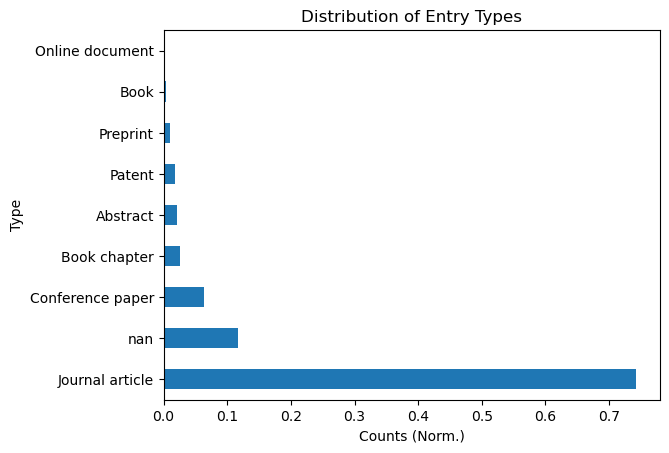

In [22]:
papers_df['Type'].value_counts(normalize = True, dropna = False).plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Entry Types')

Based on the distribution of the `Type` column, it appears that null values account for slightly over 10% of the entries, while over 70% of the entries are classified as `Journal Article`. One method of removing the null entries in the `Type` column is to isolate the data set to only have the entries categorized as `Journal Article`. By focusing solely on the entries in the `Journal Article` class, we not only eliminate any existing null values but also potentially address any class imbalances within the remaining categories. This approach may improve the accuracy of the model at classifying citations into their publication tier, as it specifically trains the model to recognize features that are most predictive to classify citations of journals and not other publication types.

In [23]:
idx = papers_df[papers_df['Type'] != 'Journal article'].index
papers_df = papers_df.drop(idx).reset_index(drop = 'True')

Let's look at the remaining null values.

In [24]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

Year              0.048214
Authors           0.036161
Source            0.004018
Cites             0.000000
Title             0.000000
CitesURL          0.000000
GSRank            0.000000
QueryDate         0.000000
Type              0.000000
CitationURL       0.000000
ECC               0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
profile_id        0.000000
dtype: float64

Since the remaining null entries *combined* represent < 0.1% of the total entries in `papers_df`. Let's drop the entries containing any null values.

In [25]:
rows_before, cols_before = papers_df.shape

In [26]:
papers_df = papers_df.dropna().reset_index(drop = True)

In [27]:
rows_after, cols_after = papers_df.shape

In [28]:
per_before = rows_after/rows_before
print('After dropping the entries containing any null values, papers_df still maintains {:0.3%} of its original entries'.format(per_before))
print(f"That's {rows_after} entries")

After dropping the entries containing any null values, papers_df still maintains 99.912% of its original entries
That's 24867 entries


We still have over 20,000 entries which is a healthy amount.

Let's look at the distribution of remaining null values.

In [29]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Cites             0.0
Authors           0.0
Title             0.0
Year              0.0
Source            0.0
CitesURL          0.0
GSRank            0.0
QueryDate         0.0
Type              0.0
CitationURL       0.0
ECC               0.0
CitesPerYear      0.0
CitesPerAuthor    0.0
AuthorCount       0.0
profile_id        0.0
dtype: float64

Let's check the null value distribution.

In [30]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

Cites             0.0
Authors           0.0
Title             0.0
Year              0.0
Source            0.0
CitesURL          0.0
GSRank            0.0
QueryDate         0.0
Type              0.0
CitationURL       0.0
ECC               0.0
CitesPerYear      0.0
CitesPerAuthor    0.0
AuthorCount       0.0
profile_id        0.0
dtype: float64

Hurray! There are zero remaining null values for `papers_df`. To conclude, we successfully removed all the null values in the `papers_df` to create a data frame of citation entries. We found the most effective method of removing null values was to isolate the data set only to include entries with `Types` values `Journal article` and removing columns that had over 99% of the entries as null and removing columns that described indexing information for the citation such as `Volume`, `StartPage`, `EndPage` and `Issue`. 

---

## 1.3 Building `jour_df` 

The goal of **Section 1.3** is to concatenate the individual data set pulled from [Scimago Journal & Country Rank](https://www.scimagojr.com/journalrank.php) into a single data frame called `jour_df`.

Given the scope of researchers who have published work in perovskites, we have pulled publications from the following subject areas:
- Materials Science
- Environmental Science
- Engineering
- Energy
- Chemistry
- Physics and Astronomy
- Chemical Engineering
- Multidisciplinary (contains journals of interest such as Nature and Science)

To ensure the successful conversion of the original data from the CSV file into a Pandas data frame, we must first perform preliminary text format editing. We accomplish this by iterating through the lines in the CSV file and using the `.replace()` method to modify any strings that require reformatting. We then append each line, whether edited or not, to a `txt` file that will be utilized in generating the Pandas data frame. Our specific modification involves replacing instances of `&amp;` with `&amp;`, as the delimiter is `;` and we want to avoid the columns splitting the string after `&amp;`.

*Note*: Attempts were made to edit the CSV files directly, but this ended up being the most effective method.

In [31]:
folder_path = r'RawData\SciMago'
folder_out = r'RawData\SciMago\output'
folder = os.listdir(folder_path)[1:] # excludes the output directory

print('Here are the CSV Files being Edited:')
for file in folder:
    path = os.path.join(folder_path, file)
    print(file)
    out_path = os.path.join(folder_out, file).replace('.csv', '')
    with open(path, 'r') as f:
        with open(out_path + '_out.txt', 'a') as g:
            for idx, line in enumerate(f):
                    # need to replace '&amp' with &
                    new_line = line.replace('&amp;', '&')
                    g.write(new_line)

Here are the CSV Files being Edited:
scimagojr 2021  Subject Area - Chemical Engineering.csv
scimagojr 2021  Subject Area - Chemistry.csv
scimagojr 2021  Subject Area - Energy.csv
scimagojr 2021  Subject Area - Engineering.csv
scimagojr 2021  Subject Area - Environmental Science.csv
scimagojr 2021  Subject Area - Materials Science.csv
scimagojr 2021  Subject Area - Multidisciplinary.csv
scimagojr 2021  Subject Area - Physics and Astronomy.csv


Next, we will concatenate the individual data frames stored in the `txt` files into one data frame titled `jour_df`.

In [32]:
folder = os.listdir(folder_out)

jour_df = pd.DataFrame()

print('Here are the TXT Files being Edited:')
for file in folder:
    path = os.path.join(folder_out, file)
    print(file)
    temp_file = np.genfromtxt(path, delimiter=';', usecols = (2,3,5,7,15,16), dtype = '<U500')
    temp_df = pd.DataFrame(temp_file[1:], columns = temp_file[0,:])
    jour_df = pd.concat([jour_df, temp_df], axis = 0)

Here are the TXT Files being Edited:
scimagojr 2021  Subject Area - Chemical Engineering_out.txt
scimagojr 2021  Subject Area - Chemistry_out.txt
scimagojr 2021  Subject Area - Energy_out.txt
scimagojr 2021  Subject Area - Engineering_out.txt
scimagojr 2021  Subject Area - Environmental Science_out.txt
scimagojr 2021  Subject Area - Materials Science_out.txt
scimagojr 2021  Subject Area - Multidisciplinary_out.txt
scimagojr 2021  Subject Area - Physics and Astronomy_out.txt


Here is the resulting data frame `jour_df`

In [33]:
jour_df.head(4)

,Title,Type,SJR,H index,Country,Region
0,"""Nature Biotechnology""",journal,"20,120",463,United Kingdom,Western Europe
1,"""Nature Catalysis""",journal,"12,887",84,United States,Northern America
2,"""Nature Reviews Chemistry""",journal,"11,811",67,United Kingdom,Western Europe
3,"""Nature Nanotechnology""",journal,"11,698",368,United Kingdom,Western Europe


In [34]:
row, col = jour_df.shape
print(f'The data frame has {row} rows and {col} columns')

The data frame has 354341 rows and 6 columns


Here are the descriptions of the columns that make up `jour_df` (pulled from https://www.scimagojr.com/journalrank.php)

- `Title`: The title of the publication 

- `Type`: The type of publication (journal article, book, etc.)

- `SJR`: *SCImago Journal Rank indicator*. It is a measure of journal's impact, influence or prestige. It expresses the average number of years weighted citations received in the selected year by the documents published in the journal in the three previous years.

- `H index`: "Journal's number of citations (h) that have received at least h citations over the whole period"

- `Country`: The location of the publisher.

- `Region`: The region of the publisher's country.

To summerize, in this section we imported a data set of publications and their metrics as the data frame `jour_df` to be able to add additional features to `paper_df` that would describe an entry's rank.

---

## 1. 4 Cleaning `jour_df`

The goal of **Section 1.4** is to reduce the occurrence of null values and duplicated entries. 


Additionally in such that we can *join* the titles of the publications onto the publication titles in the `papers_df`.

First, let's check to see if `jour_df` has any duplicate entries. We'd expect there to be duplicate publication entires if a publication is present in more than one subject area's data frame. (Example: the publication `ACS Nano` could be considered to span both the Materials Science and Chemistry subject area, so it would be added to `jour_df` from both subject area data frames).

In [35]:
num = jour_df.duplicated().sum()
print(f'There are {num} duplicated entires')

There are 347819 duplicated entires


Let's remove the duplicated entries.

In [36]:
jour_df = jour_df.drop_duplicates(ignore_index = True)

In [37]:
num = jour_df.duplicated().sum()
print(f'There are {num} duplicated entires')

There are 0 duplicated entires


In [38]:
row, col = jour_df.shape
print(f'The data frame has {row} rows and {col} columns')

The data frame has 6522 rows and 6 columns


It looks like most of the entires in `jour_df` were duplicated since the the data frame originally had over 57,000 entries and now has about 6,5000.

Let's look at some formatting changes we can make to the entires.

In [39]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,"""Nature Biotechnology""",journal,"20,120",463,United Kingdom,Western Europe
1,"""Nature Catalysis""",journal,"12,887",84,United States,Northern America
2,"""Nature Reviews Chemistry""",journal,"11,811",67,United Kingdom,Western Europe
3,"""Nature Nanotechnology""",journal,"11,698",368,United Kingdom,Western Europe
4,"""Nature Chemistry""",journal,"8,384",249,United Kingdom,Western Europe


In [40]:
jour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6522 entries, 0 to 6521
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Title    6522 non-null   object
 1   Type     6522 non-null   object
 2   SJR      6522 non-null   object
 3   H index  6522 non-null   object
 4   Country  6522 non-null   object
 5   Region   6522 non-null   object
dtypes: object(6)
memory usage: 305.8+ KB


`Title`, `Type` `Country` and `Region` appear to be assigned the appropriate data type (object) while `SJR` and `H index` should be changed to a numeric data type. First, let's  replace `,` with `.` in `SJR` so it can be interpreted as a `float` and then convert `SJR` and `H index` into numeric data types.

In [41]:
jour_df = jour_df.assign(SJR = jour_df.apply(lambda x: x['SJR'].replace(',', '.'), axis = 1))

In [42]:
for idx in jour_df['H index'].index:
    try: 
        # try to convert str to integer
        jour_df.loc[idx, 'H index'] = int(jour_df.loc[idx, 'H index'])
    except:
        # set value to null if the changing the data type doesn't work
        jour_df.loc[idx, 'H index'] = np.nan 
    
# Convert to float data type (using float insted of int because I can't conver NAN to int)
jour_df['H index'] = jour_df['H index'].astype('float16')

for idx in jour_df['SJR'].index:
    try: 
        # try to convert string to float
        jour_df.loc[idx, 'SJR'] = float(jour_df.loc[idx, 'SJR'])
    except:
        # set value to null if the changing the data type doesn't work
        jour_df.loc[idx, 'SJR'] = np.nan

# Convert to float data type
jour_df['SJR'] = jour_df['SJR'].astype('float64')

In [43]:
jour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6522 entries, 0 to 6521
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    6522 non-null   object 
 1   Type     6522 non-null   object 
 2   SJR      6433 non-null   float64
 3   H index  6520 non-null   float16
 4   Country  6522 non-null   object 
 5   Region   6522 non-null   object 
dtypes: float16(1), float64(1), object(4)
memory usage: 267.6+ KB


In [44]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,"""Nature Biotechnology""",journal,20.120,463.0,United Kingdom,Western Europe
1,"""Nature Catalysis""",journal,12.887,84.0,United States,Northern America
2,"""Nature Reviews Chemistry""",journal,11.811,67.0,United Kingdom,Western Europe
3,"""Nature Nanotechnology""",journal,11.698,368.0,United Kingdom,Western Europe
4,"""Nature Chemistry""",journal,8.384,249.0,United Kingdom,Western Europe


It looks like the data type of `SJR` and `H index` successfully changed into numeric data types! Now let's continue editing the format of the `Title` column .Let's start with remove `""` from the values in `Title`.

In [45]:
jour_df["Title"] = jour_df["Title"].str.replace('"', '')

In [46]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,Nature Biotechnology,journal,20.120,463.0,United Kingdom,Western Europe
1,Nature Catalysis,journal,12.887,84.0,United States,Northern America
2,Nature Reviews Chemistry,journal,11.811,67.0,United Kingdom,Western Europe
3,Nature Nanotechnology,journal,11.698,368.0,United Kingdom,Western Europe
4,Nature Chemistry,journal,8.384,249.0,United Kingdom,Western Europe


Let's also strip an white space from the remaining object columns for good measure.

In [47]:
for col in jour_df.select_dtypes('object').columns:
    jour_df[col] = jour_df[col].str.strip()

In [48]:
jour_df.head(5)

,Title,Type,SJR,H index,Country,Region
0,Nature Biotechnology,journal,20.120,463.0,United Kingdom,Western Europe
1,Nature Catalysis,journal,12.887,84.0,United States,Northern America
2,Nature Reviews Chemistry,journal,11.811,67.0,United Kingdom,Western Europe
3,Nature Nanotechnology,journal,11.698,368.0,United Kingdom,Western Europe
4,Nature Chemistry,journal,8.384,249.0,United Kingdom,Western Europe


Let's see if implimenting those formatting changes introduced any new duplicate rows.

In [49]:
num = jour_df.duplicated().sum()
print(f'There are {num} duplicated entires')

There are 0 duplicated entires


There are no duplicated entries, but there may duplicated values in `Title`.

In [50]:
num = jour_df.duplicated('Title').sum()
print(f'There are {num} duplicated entires in Title')

There are 5 duplicated entires in Title


It appears that there are repeated values in `Title`. Let's try to find them.

In [51]:
jour_df[jour_df.duplicated('Title')]

,Title,Type,SJR,H index,Country,Region
1743,Water and Energy International,journal,0.116,9.0,India,Asiatic Region
3386,Engineering Journal,trade journal,0.254,25.0,United States,Northern America
3410,Journal of Marine Science and Technology,journal,0.249,29.0,Taiwan,Asiatic Region
4099,Journal of Engineering Research,journal,0.116,11.0,Oman,Middle East
4243,Engineering,journal,0.101,2.0,United Kingdom,Western Europe


These are the entries that have duplicate values for `Title`. Let's sample 3 of the duplicates.

In [52]:
jour_df[jour_df['Title'] == 'Engineering']

,Title,Type,SJR,H index,Country,Region
50,Engineering,journal,1.614,59.0,United Kingdom,Western Europe
4243,Engineering,journal,0.101,2.0,United Kingdom,Western Europe


In [53]:
jour_df[jour_df['Title'] == 'Engineering Journal']

,Title,Type,SJR,H index,Country,Region
3319,Engineering Journal,journal,0.270,22.0,Thailand,Asiatic Region
3386,Engineering Journal,trade journal,0.254,25.0,United States,Northern America


In [54]:
jour_df[jour_df['Title'] == 'Journal of Marine Science and Technology']

,Title,Type,SJR,H index,Country,Region
2324,Journal of Marine Science and Technology,journal,0.771,50.0,Japan,Asiatic Region
3410,Journal of Marine Science and Technology,journal,0.249,29.0,Taiwan,Asiatic Region


From the sample of 3 journals with repeated values for `Title`, it looks like the duplications originate from a publication with the same name having a different country of origin, or metric such as `H index`. To reduce confusion when joining the `papers_df` on the `jour_df`, let's remove duplicate entries with the lower `H index` value, since its less likely to be the publication that the citation is referring to.

In [55]:
# First sort the entires so that entires with a higher H index is sorted first, therefore the duplicated entries with the lower entries will be deleted.
jour_df = jour_df.sort_values('H index', ascending= False).drop_duplicates('Title', keep = 'first')

In [56]:
num = jour_df.duplicated('Title').sum()
print(f'There are {num} duplicated entires in Title')

There are 0 duplicated entires in Title


It looks like duplicated entires were properly addressed!

Next, let's assess the null values in the data frame.

In [57]:
jour_df.isna().sum()

Title       0
Type        0
SJR        89
H index     2
Country     0
Region      0
dtype: int64

It looks like `SJR` and `H index` have the most null values. Let's investigate the null values in the `SJR` column.

In [58]:
jour_df[jour_df['SJR'].isna()].head(5)

,Title,Type,SJR,H index,Country,Region
663,Advances in Biochemical Engineering/Biotechnology,journal,NaN,92.0,Germany,Western Europe
4339,Conference Record - IAS Annual Meeting (IEEE I...,conference and proceedings,NaN,83.0,United States,Northern America
5664,Fresenius Environmental Bulletin (discontinued),journal,NaN,41.0,Germany,Western Europe
4340,Conference Record - IEEE Instrumentation and M...,conference and proceedings,NaN,39.0,United States,Northern America
1350,Revista de Chimie (discontinued),journal,NaN,31.0,Romania,Eastern Europe


From investigating the entires on the [website](https://www.scimagojr.com/), it appears that the null entries are due to the website having no data on to generate a `SJR` value for the journal. For now, let's leave those columns as null values and decide to keep them once we combined the entires in `jour_df` with `papers_df`.

Let's investigate the entires with null values for `H index`

In [59]:
jour_df[jour_df['H index'].isna()].head(5)

,Title,Type,SJR,H index,Country,Region
674,Title,Type,NaN,NaN,Country,Region
6257,Numerical Heat Transfer,"Part A: Applications""",NaN,NaN,"33,56",United Kingdom


It looks like the first row (index = 674) is just the heading, so that row can be deleted.

In [60]:
jour_df = jour_df.drop(674)

The second row (index = 6257) appears to be an entry that needs to be manually reformatted. Let's look at that row more closely.

In [61]:
jour_df.loc[6257, :]

Title      Numerical Heat Transfer
Type         Part A: Applications"
SJR                            NaN
H index                        NaN
Country                      33,56
Region              United Kingdom
Name: 6257, dtype: object

We can use the information [directly from the website](https://www.scimagojr.com/journalsearch.php?q=21578&tip=sid&clean=0) to reformat this entry.

In [62]:
jour_df.loc[6257, :] = ['Numerical Heat Transfer; Part A: Applications', 'journal', 0.684 ,75, 'United Kingdom', 'Western Europe']

Now let's look at the null values.

In [63]:
jour_df.isna().sum()

Title       0
Type        0
SJR        87
H index     0
Country     0
Region      0
dtype: int64

It looks like all the `H index` null values were dropped and we dropped two null values in the `SJR` columns as well.

To start, let's investigate the values in the `Type` column to see if isolated the entries in `jour_df` to only include journal article entries will reduce the null values in `SJR`.

Text(0.5, 1.0, 'Distribution of Types')

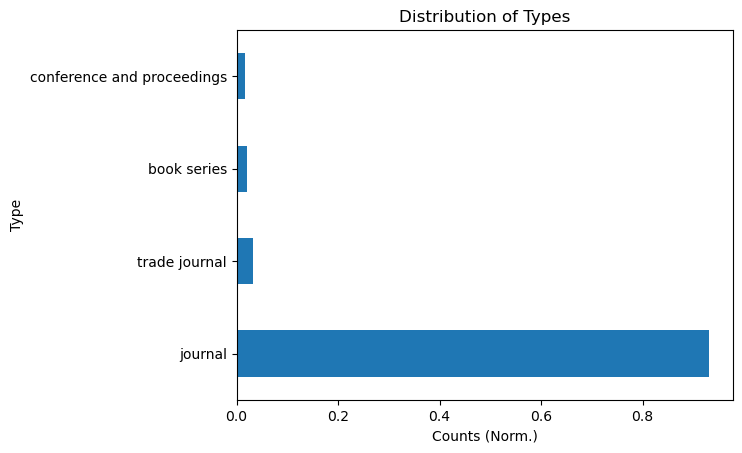

In [64]:
jour_df['Type'].value_counts(normalize = True).plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Types')

It looks like the types match up similarly with the publication types chosen for the `papers_df`. However, we have an additional category, `trade journal`, that may include some publications in the `papers_df`. Therefore, let's isolate the entries in `jour_df` to only inlcude the publications from `journal` and `trade journal`.

In [65]:
jour_df = jour_df[(jour_df['Type'] == 'journal') | (jour_df['Type'] == 'trade journal')]

Let's assess the remaining null values.

In [66]:
jour_df.isna().sum()

Title       0
Type        0
SJR        78
H index     0
Country     0
Region      0
dtype: int64

Isolating the entries to only include publications from `journal` and `trade journal` sucessfully reduced the number of null values of `SJR` by 12.

To conclude, we reduce the occurrence of null values and identify and remove duplicate entries in `jour_df` by identifying formatting errors and inconsistencies in the entries and features.

---

## 1.5 Reformatting the Publication Source Titles in `jour_df` and `papers_df` 

Our end goal is to join the values in `jour_df` onto `papers_df` using the names of the publications. For the joining to work, the names of the publications must have the same format. Therefore, we must apply a standard string format for all the values in both the `Title` column of `jour_df` and the `Source` column of `papers_df`. The format will follow the following criteria:

1. Encode the title in ASCII
2. No leading articles (Remove The, A/An at the beginning of the Titles)
3. Replace the character `&` with `and`
4. Remove remaining special characters
5. Remove double spacing
6. Remove any qualifiers such as `(discontinued)`
7. All characters are lower case

The goal of **Section 1.5** is to use the function `edit_title` to apply these formatting edits using regex

In [67]:
import re

def edit_title(row):
    '''
    
    Uses regex to edit the format of that values of publication titles.
    
    Parameters:
    ---------
    row: str
        The title of the publication source.
    
    Return:
    ------
    ret: str 
        The reformatted title of the publication source.
    
    Raises:
    ------
    - TypeError: If row is not a string.
    
    '''
    title = row
    
    if not isinstance(title, str):
        raise TypeError('Input row must be a string')

    # Encode the titles in ASCII 
    title = title.encode('ascii', 'ignore').decode('ascii')
    
    # Get rid of 'The'
    title = re.sub(r'^The\s', '', title)
    
    # Get rid of '(discontinued)'
    title = re.sub(r'\(discontinued\)', '', title)
    
    # Insert spaces in '&word' case
    title = re.sub(r'\&\+?', 'and ', title)
    
    # Get rid of special characters 
    title = re.sub(r'[!@#$%\^\*\(\)-:\.=,\+\_]', '', title)
    
    # Get rid of double spacing
    title = re.sub(r'  ', ' ', title)
    
    return title.strip().lower()

### 1.5.1 Reformatting Values in `jour_df`
We'll assign the data frame with the reformatted values for `Title` under the variable `test_df`.

In [68]:
test_df = jour_df.assign(Title = jour_df['Title'].apply(edit_title))

In [69]:
test_df.head(10)

,Title,Type,SJR,H index,Country,Region
6003,nature,journal,17.897,1276.0,United Kingdom,Western Europe
6004,science,journal,14.589,1229.0,United States,Northern America
6006,proceedings of the national academy of science...,journal,4.184,805.0,United States,Northern America
675,chemical reviews,journal,18.718,745.0,United States,Northern America
6140,physical review letters,journal,3.246,647.0,United States,Northern America
9,journal of the american chemical society,journal,5.728,644.0,United States,Northern America
11,angewandte chemie international edition,journal,5.126,579.0,United Kingdom,Western Europe
1786,advanced materials,journal,8.663,563.0,United States,Northern America
676,chemical society reviews,journal,14.529,552.0,United Kingdom,Western Europe
17,nano letters,journal,3.761,511.0,United States,Northern America


Let's check to make sure the number of unique values in `Title` are preserved.

In [70]:
result = test_df['Title'].value_counts().count() == jour_df['Title'].value_counts().count() 

if result == False:
    diff = np.abs(np.subtract(test_df['Title'].value_counts().count(), jour_df['Title'].value_counts().count()))
    if jour_df['Title'].value_counts().count() > test_df['Title'].value_counts().count():
        print(f'There are {diff} more unique values in jour_df than test_df')
    elif jour_df['Title'].value_counts().count() < test_df['Title'].value_counts().count():
        print(f'There are {diff} more unique values in test_df than jour_df')
else:
    print(result)

There are 1 more unique values in jour_df than test_df


Since there are more unique values in `jour_df` than `test_df`, that means there are two entires containing unique metrics for what would be considered as the same publication. This poses an issue since we are using the `Title` column as the primary key for `jour_df`. To help remove this ambiguity, let's see what the duplicated title is.

In [71]:
test_df.groupby('Title').size()[test_df.groupby('Title').size() > 1]

Title
biotech    2
dtype: int64

In [72]:
print('Before the formatting')
display(jour_df.loc[[4900,258], :])

print('After the formatting')
display(test_df[test_df['Title'] == 'biotech'])

Before the formatting


,Title,Type,SJR,H index,Country,Region
4900,3 Biotech,journal,0.522,49.0,Switzerland,Western Europe
258,BioTech,journal,0.530,15.0,Switzerland,Western Europe


After the formatting


,Title,Type,SJR,H index,Country,Region
4900,biotech,journal,0.522,49.0,Switzerland,Western Europe
258,biotech,journal,0.530,15.0,Switzerland,Western Europe


It looks like there is two entries for `biotech`, one that originally was lead with a 3, and another that was not. Looking up `3 Biotech` on the [website](https://www.scimagojr.com/) didn't yield any results with that specific title, so likely an importing issue caused the format of the title to be `3 Biotech` and not `Biotech`. However, the two different values of `SJR` and `H index` suggest these entries are different publications. Despite this, we will apply our prior protocol so that entry with the larger value of `H index` will be kept since it has the highest chance of people the actual publication that would be cited.

In [73]:
test_df = test_df.drop(4900)
jour_df = jour_df.drop(4900)

Let's check again to make sure the number of unique values in `Title` are preserved.

In [74]:
result = test_df['Title'].value_counts().count() == jour_df['Title'].value_counts().count() 

if result == False:
    diff = np.abs(np.subtract(test_df['Title'].value_counts().count(), jour_df['Title'].value_counts().count()))
    if jour_df['Title'].value_counts().count() > test_df['Title'].value_counts().count():
        print(f'There are {diff} more unique values in jour_df than test_df')
    elif jour_df['Title'].value_counts().count() < test_df['Title'].value_counts().count():
        print(f'There are {diff} more unique values in test_df than jour_df')
else:
    print(result)

True


The value counts match! Next, let's check for any blank values in `Title` since encoding the values in ASCII would leave an empty string if there were no English letters, numbers or specific special characters.

In [75]:
test_df['Title'][test_df['Title'] == ''].count()

0

There are no blank values in the `Title` column. Finally, let's check the null values in `test_df`.

In [76]:
test_df.isna().sum()

Title       0
Type        0
SJR        78
H index     0
Country     0
Region      0
dtype: int64

There are no additional null values introduced. Let's replace `jour_df` with the data frame stored in `test_df`.

In [77]:
jour_df = test_df.reset_index(drop = True)

### 1.5.1 Reformatting Values in `papers_df`

In `papers_df`, the name of the publication is stored in the column `Source`. Let's pass the values in `Source` into the same formatting method `edit_title` applied on the `Title` column of `jour_df`. Similarly to the process we applied in part 2, we'll assign the data frame with the reformatted values for `Source` under the variable `test_df`.

In [78]:
test_df = papers_df.assign(Source = papers_df['Source'].apply(edit_title))

In [79]:
test_df['Source'].sample(10)

2769                       scientific reports
22581                          nanotechnology
8826                  physica status solidi a
10651    acs applied materials and interfaces
7399                    journal of microscopy
5820                         nature materials
23240               physical review materials
23776                      scientific reports
24445           advanced functional materials
10883                               acs omega
Name: Source, dtype: object

Let's check to make sure the number of unique values in `Source` are preserved.

In [80]:
result = test_df['Source'].value_counts().count() == papers_df['Source'].value_counts().count() 

if result == False:
    diff = np.abs(np.subtract( test_df['Source'].value_counts().count(), papers_df['Source'].value_counts().count()))
    if papers_df['Source'].value_counts().count() > test_df['Source'].value_counts().count():
        print(f'There are {diff} more unique values in papers_df than test_df')
    elif papers_df['Source'].value_counts().count() < test_df['Source'].value_counts().count():
        print(f'There are {diff} more unique values in test_df than papers_df')
else:
    print(result)

There are 818 more unique values in papers_df than test_df


We lost some unique values in `Source` between `papers_df` in `test_df`. However, unlike the `Title` column in `jour_df`, we don't need to worry about the loss of unique publication titles since `Source` won't be the primary key to join `papers_df` and `jour_df`, rather it is the foreign key for `papers_df`. If anything, the loss of 818 unique titles will hopefully ensure more entires in `papers_df` will be able to join to `jour_df` since their formatting is consistent.

Next, let's check if there are any blank values in the `Source` column of the `test_df`

In [81]:
test_df['Source'][test_df['Source'] == ''].count()

107

There are 107 entires with blank values in `papers_df`. These were expected since there were entires that used alphabets other than English, such as Russian, Mandarin, and Korean. Ideally, we could attempt to translate the names of these entries into English to see if there are matching entires in `jour_df`, but for the sake of time we will delete these entries since they only represent about 0.3% of the entires.

In [82]:
test_df = test_df.drop(test_df['Source'][test_df['Source'] == ''].index)

Let's double check to make sure all the blank entires were accounted for.

In [83]:
test_df['Source'][test_df['Source'] == ''].count()

0

All the blank entries were successfully removed. Now let's check for null values in `Source`

In [84]:
test_df['Source'].isna().sum()

0

There are no additional null values introduced. Let's replace `papers_df` with the data frame stored in `test_df`.

In [85]:
papers_df = test_df.reset_index(drop = True)

To conclude, in this section we cleaned the columns `jour_df` to ensure each column was assigned to an appropriate data type, and to ensure the formatting of the publication titles for `paper_df` and `jour_df` were consistent so that they could act as keys to join the data frames.

---

## 1.6 Optimizing `papers_df` and `jour_df` for Memory Efficiency 

The goal of **Part 3** is to modify the entries and features of `papers_df` and `join_df` so that the data frame uses the least amount of memory possible. This is assist with loading and modifying the data frame in the future.

### 1.6.1 Optimizing `papers_df`

Let's start by look examining data types assigned to the columns in `papers_df`.

In [86]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24760 entries, 0 to 24759
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24760 non-null  int64  
 1   Authors         24760 non-null  object 
 2   Title           24760 non-null  object 
 3   Year            24760 non-null  float64
 4   Source          24760 non-null  object 
 5   CitesURL        24760 non-null  object 
 6   GSRank          24760 non-null  int64  
 7   QueryDate       24760 non-null  object 
 8   Type            24760 non-null  object 
 9   CitationURL     24760 non-null  object 
 10  ECC             24760 non-null  int64  
 11  CitesPerYear    24760 non-null  float64
 12  CitesPerAuthor  24760 non-null  int64  
 13  AuthorCount     24760 non-null  int64  
 14  profile_id      24760 non-null  float64
dtypes: float64(3), int64(5), object(7)
memory usage: 2.8+ MB


Here, we see that `papers_df` currently takes up over 2.8 MB of memory and that each of the numeric data types are 64 bit. Let's see if we can change the data types of the numeric data so that `papers_df` uses less memory. We can do so by writing a script that finds the max value in the feature and assigning the lowest memory data type to that feature that can precisely store that value.

For example, assuming the maximum value of the entries in `Year` is 2023 (the current year), we can write a script that checks if 2023 is less than the maximum value of each integer type up to `int64` and assigns the smallest data type to `Year` that meets that condition. The maximum values of each data types are shown in the table below:

In [87]:
import tabulate
arr = np.zeros([4,4], dtype = object)

arr[:,2] = np.asarray([8, 16, 32, 64]) #bits
arr[:,0] = np.asarray([f'int{i}' for i in arr[:,2]]) # integer type
arr[:,1] = np.asarray(['None'] + [f'float{i}' for i in arr[1:,2]]) # float type
arr[:,3] = np.asarray([(2**i)/2 for i in arr[:,2]]) # max values

# Making a new arr for display purposes
display_arr = arr.copy()
display_arr[:,3] = np.asarray(['{:,}'.format(int((2**i)/2)) for i in arr[:,2]]) # formatting values of MaxiumValue
tabulate.tabulate(display_arr, tablefmt='html', headers=('IntegerType', 'FloatType', 'Bits', "MaximumValue"), stralign='center', numalign = 'center')

IntegerType,FloatType,Bits,MaximumValue
int8,None,8,128
int16,float16,16,"32,768"
int32,float32,32,"2,147,483,648"
int64,float64,64,"9,223,372,036,854,775,808"


Here, since 2023 is less than 32,768 but larger than 128 `Year` would be assigned to a 16 bit type. More specifically, since years don't have any decimals, it would assigned to `int16`. To start, we'll begin by assigning integer data types to numeric columns that already assigned an integer data type, as well as columns that assigned to be floats but should actually be integers (example, `Year` and `profile_id`).

In [88]:
# Only CitesPerYear is an actual float type, all else will be considerd as integer types
num_cols = papers_df.select_dtypes('number').drop(['CitesPerYear'],axis = 1).columns

for col in num_cols:
    max_val = papers_df[col].max()
    print(f'The max value in the {col} column is {max_val}')
    for i in range(arr[:,3].shape[0]): # iterating over the rows of the MaximumValues
        if max_val < int(arr[i,3]):
            print(f'The type for {col} is being changed to {arr[i,0]}')
            print('\n')
            papers_df[col] = papers_df[col].astype(arr[i,0])
            break

The max value in the Cites column is 9210
The type for Cites is being changed to int16


The max value in the Year column is 2023.0
The type for Year is being changed to int16


The max value in the GSRank column is 990
The type for GSRank is being changed to int16


The max value in the ECC column is 9210
The type for ECC is being changed to int16


The max value in the CitesPerAuthor column is 2400
The type for CitesPerAuthor is being changed to int16


The max value in the AuthorCount column is 12
The type for AuthorCount is being changed to int8


The max value in the profile_id column is 615.0
The type for profile_id is being changed to int16




In [89]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24760 entries, 0 to 24759
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24760 non-null  int16  
 1   Authors         24760 non-null  object 
 2   Title           24760 non-null  object 
 3   Year            24760 non-null  int16  
 4   Source          24760 non-null  object 
 5   CitesURL        24760 non-null  object 
 6   GSRank          24760 non-null  int16  
 7   QueryDate       24760 non-null  object 
 8   Type            24760 non-null  object 
 9   CitationURL     24760 non-null  object 
 10  ECC             24760 non-null  int16  
 11  CitesPerYear    24760 non-null  float64
 12  CitesPerAuthor  24760 non-null  int16  
 13  AuthorCount     24760 non-null  int8   
 14  profile_id      24760 non-null  int16  
dtypes: float64(1), int16(6), int8(1), object(7)
memory usage: 1.8+ MB


Here we see that applying this method lowered the memory usage for `papers_df` by 1 MB. Let's repeat the same process but for the float type column `CitesPerYear`.

In [90]:
# Only CitesPerYear is an actual float type, all else will be considerd as integer types
num_cols = ['CitesPerYear']

for col in num_cols:
    max_val = papers_df[col].max()
    print(f'The max value in the {col} column is {max_val}')
    for i in range(arr[:,3].shape[0]): # iterating over the rows of the MaximumValues
        if max_val < int(arr[i,3]):
            print(f'The type for {col} is being changed to {arr[i,1]}')
            print('\n')
            papers_df[col] = papers_df[col].astype(arr[i,1])
            break

The max value in the CitesPerYear column is 921.0
The type for CitesPerYear is being changed to float16




In [91]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24760 entries, 0 to 24759
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24760 non-null  int16  
 1   Authors         24760 non-null  object 
 2   Title           24760 non-null  object 
 3   Year            24760 non-null  int16  
 4   Source          24760 non-null  object 
 5   CitesURL        24760 non-null  object 
 6   GSRank          24760 non-null  int16  
 7   QueryDate       24760 non-null  object 
 8   Type            24760 non-null  object 
 9   CitationURL     24760 non-null  object 
 10  ECC             24760 non-null  int16  
 11  CitesPerYear    24760 non-null  float16
 12  CitesPerAuthor  24760 non-null  int16  
 13  AuthorCount     24760 non-null  int8   
 14  profile_id      24760 non-null  int16  
dtypes: float16(1), int16(6), int8(1), object(7)
memory usage: 1.7+ MB


The memory usage for `papers_df` was reduced by 0.1 MB. Now, let's assess the object type columns. For training and testing a model, we want columns represented numerically, so unless an object column serves another purpose, it should either be excluded from the data set or be represented numerically. We want to keep `Authors` and `Source` as object data types since we plan to engineer those values to serve as foreign and primary keys. Additionally, `Title` should be kept as a unique identifier between citation entries. In contrast, the columns `CitesURL` and `CitationURL` can be removed since they don't contain any information about the citations we can use to determine their prestige ranking. Additionally, `QueryDate` can be removed since we queried all the entries on the same day. Therefore, let's remove the columns with object data type besides `Authors`,`Source` and `Title`.

In [92]:
papers_df = papers_df.drop(['CitesURL', 'CitationURL', 'QueryDate'], axis = 1)

In [93]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24760 entries, 0 to 24759
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24760 non-null  int16  
 1   Authors         24760 non-null  object 
 2   Title           24760 non-null  object 
 3   Year            24760 non-null  int16  
 4   Source          24760 non-null  object 
 5   GSRank          24760 non-null  int16  
 6   Type            24760 non-null  object 
 7   ECC             24760 non-null  int16  
 8   CitesPerYear    24760 non-null  float16
 9   CitesPerAuthor  24760 non-null  int16  
 10  AuthorCount     24760 non-null  int8   
 11  profile_id      24760 non-null  int16  
dtypes: float16(1), int16(6), int8(1), object(4)
memory usage: 1.1+ MB


Reducing the number of object columns reduced the memory usage of `paper_df` by 0.6 MB! Overall, modifying the data types of the numeric entries and reduced the number of object columns in `papers_df` reduced its memory usage by 1.7 MB (39%).

### 1.6.2 Optimizing `jour_df`

Let's start by look examining data types assigned to the columns in `jour_df`.

In [94]:
jour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    6276 non-null   object 
 1   Type     6276 non-null   object 
 2   SJR      6198 non-null   float64
 3   H index  6276 non-null   float16
 4   Country  6276 non-null   object 
 5   Region   6276 non-null   object 
dtypes: float16(1), float64(1), object(4)
memory usage: 257.5+ KB


`jour_df` currently only uses 306.4 KB of memory. It looks like we only have two columns that are numeric data types, `SJR` and `H index`. While `SJR` is a real float, `H index` should be an integer. Let's use the same method applied to `papers_df` to assign new numeric data types to `jour_df`.

In [95]:
# Only CitesPerYear is an actual float type, all else will be considerd as integer types
num_cols = jour_df.select_dtypes('number')

for col in num_cols:
    max_val = jour_df[col].max()
    print(f'The max value in the {col} column is {max_val}')
    
    for i in range(arr[:,3].shape[0]): # iterating over the rows of the MaximumValues 
           
        # Checking to see if max_val is less than the MaximumValue
        if max_val < int(arr[i,3]):
            
            # defining new data type for integer vs float
            if col == 'SJR':
                new_type = arr[i,1]
            elif col != 'SJR':
                new_type = arr[i,0]
        
            # assigning the new data type
            if new_type != 'None':
                print(f'The type for {col} is being changed to {new_type}')
                print('\n')
                jour_df[col] = jour_df[col].astype(new_type)
                break

The max value in the SJR column is 25.045
The type for SJR is being changed to float16


The max value in the H index column is 1276.0
The type for H index is being changed to int16




In [96]:
jour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Title    6276 non-null   object 
 1   Type     6276 non-null   object 
 2   SJR      6198 non-null   float16
 3   H index  6276 non-null   int16  
 4   Country  6276 non-null   object 
 5   Region   6276 non-null   object 
dtypes: float16(1), int16(1), object(4)
memory usage: 220.8+ KB


Changing the data types of the numeric columns reduced memory usage of `jour_df` by 36.7 KB! Let's look at the object columns. `Title` will serve as the primary key to join `papers_df` with `jour_df` so it must stay as-is. We should also keep `Type` as its information could prove to be informative when joining the `jour_df` and `papers_df` together. Let's look at the distribution of values in `Country` and `Region` to determine if the information could be useful.

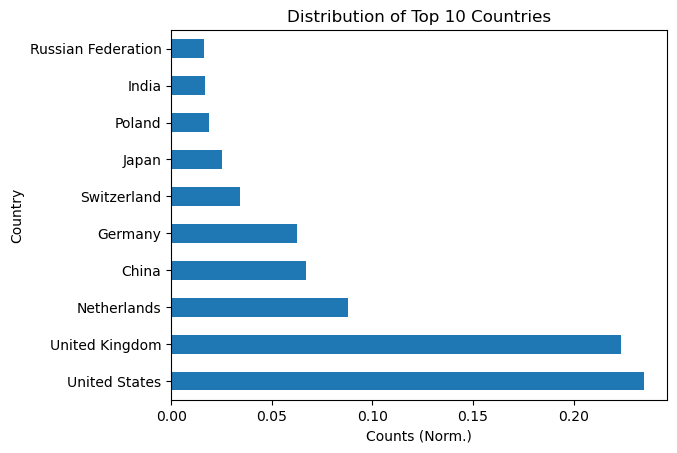

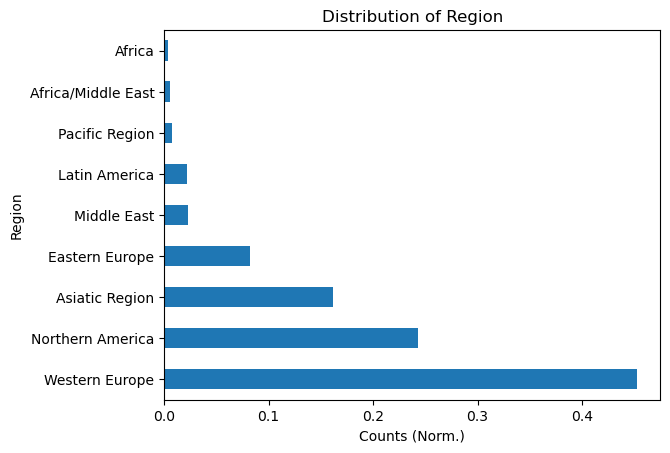

In [97]:
jour_df['Country'].value_counts(normalize = True)[:10].plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Top 10 Countries')
plt.show()

jour_df['Region'].value_counts(normalize = True).plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Region')
plt.show()

In [98]:
jour_df[['Country', 'Region']].describe()

,Country,Region
count,6276,6276
unique,84,9
top,United States,Western Europe
freq,1473,2837


With 84 countries and the United States, United Kingdom and Netherlands alone accounting for 50% of the counts, `Country` might not be helpful in ranking the entries but could be used as an interesting metric to see the distribution of publishing locations for the entries in `papers_df`. The same can be said for the values in `Region` as well. Therefore, let's keep all the object columns in the data frame.

Overall, modifying the data types of the numeric entries reduced its memory usage by 1.7 MB (11.9%).

---

## 1.7 Joining `papers_df` with `jour_df`

The objective of **Section 1.7** is to attempt to merge `papers_df` with `jour_df` on the publication titles. We will use a left join in order to preserve the columns in the `papers_df` that weren't able to join to `jour_df` for investigation. We will call the joined data frame `join_df`.

In [99]:
def get_merge_per():
    '''
    
    This function uses the global variables for papers_df, jour_df and entry_goal to computes the percentage of merged entries 
    in the `join_df` compared to the original number of entries in the `papers_df`. 
    
    Also calculates the number of remaining rows left to be merged to reach a predefined entry goal.
    
    Parameters:
    ---------
    None
    
    Return:
    -----
    ret: pandas.DataFrame 
        The data frame join_df that contains the left-joined papers_df and jour_df
    
    '''
    global papers_df, jour_df, entry_goal, og_entries

    join_df = pd.merge(left = papers_df, right = jour_df, left_on = 'Source', right_on = 'Title', how = 'left')

    entries_merged = (join_df['Title_y'].isna() == False).sum()
    non_nulls_per = entries_merged/og_entries
    diff = entry_goal - entries_merged
    
    print("{:.2%} of the original entries merged!".format(non_nulls_per))
    print(f'{round(diff)} rows left to go!')
    return join_df

### 1.7.1 Establishing Methods of Identifying Formatting Inconsistencies

In [100]:
og_entries = papers_df.shape[0]
entry_goal = og_entries*0.90
print('The number of entries to aim for is', round(entry_goal))

The number of entries to aim for is 22284


In [101]:
join_df = get_merge_per()

85.92% of the original entries merged!
1010 rows left to go!


Luckily, over 85% of the entries so we're starting off strong! Let's investigate the values in `Source` that didn't merge with `Title` to see where we could make some formatting adjustments to merge more rows. Note, the cell below was executed multiple times to take in a different sample of 10 values to get an idea of the title variations, so the title variations discussed below it may differ from what would be initially outputted in the cell.

In [102]:
# I executed this line multiple times to get an idea of some of the title variations
join_df['Source'][join_df['Title_y'].isna()].sample(10).value_counts()

Source
journal of porphyrins and phthalocyanines n              1
chem commun                                              1
ecs transactions                                         1
reaction kinetics and catalysis letters                  1
zeitschrift fr physikalische chemie                      1
organic lightemitting materials and devices              1
journal of physics materials                             1
journal of nanoscience and nanotechnology                1
nonlinear optical properties of organic materials vii    1
chinese physical soc po box beijing peoples r china      1
Name: count, dtype: int64

One pattern that was noticed was that there would often been variations of publications, notably `science` and `science advances` that were followed by a code, usually beginning with `ea`. Let's look at the distribution of those variables specifically.

In [103]:
join_df['Source'][join_df['Source'].str.contains(r'^science', regex = True)].value_counts()

Source
science                                          127
science advances                                  25
science china chemistry                           14
science of advanced materials                     12
science bulletin                                  10
science china materials                            9
science advances  eabb                             8
science advances  eabq                             7
science advances  eabf                             5
science and technology of advanced materials       5
science advances  eabj                             5
science advances  eaay                             4
science advances  eabc                             4
science advances  eaav                             3
science advances  eabg                             3
science advances  eabd                             3
science of the total environment                   2
science and technology                             2
science advances  eaao                 

Let's pull up the titles of a paper that has a suffix `eabq`

In [104]:
papers_df['Title'][papers_df['Source'] == 'science advances  eabq'].values[0]

'Momentum-matching and band-alignment van der Waals heterostructures for high-efficiency infrared photodetection'

From that paper's [citation](https://scholar.google.com/scholar?hl=en&as_sdt=0%2C5&q=Momentum-matching+and+band-alignment+van+der+W&btnG=#d=gs_cit&t=1679502207047&u=%2Fscholar%3Fq%3Dinfo%3AH-GM87rXWl0J%3Ascholar.google.com%2F%26output%3Dcite%26scirp%3D0%26hl%3Den) it appears that the `eabq` was accidentally pulled from the page number and appended to the title. The page number beginning with `ea` seems to be a consistent trend across both papers published in `science` and `science advances` so let's reformat those names so that those suffixes no longer exist. We will store the results in `test_df` to inspect before overwriting `papers_df`, and consequently, `jour_df`.

In [105]:
def remove_pattern(val, pattern, method = 'no_space'):
    
    '''
    This function uses regex to remove specific patterns from strings.
    
    Parameters:
    --------- 
    val: str
        A string to be checked for a matching pattern.
    pattern: str 
        The pattern to impliment
    method: str (default = 'no_space') 
        Sets if there needs to be a space kept when removing the pattern.
    
    Return:
    ------
    ret: str 
        The string with the pattern removed
        
    Raises:
    ------
    - TypeError: If pattern or val are not strings.
    
    '''
    if not isinstance(pattern, str):
        raise TypeError("pattern must be a string")
    if not isinstance(val, str):
        raise TypeError("val must be a string")
    
    if method == 'no_space':
        return re.sub(pattern, '', val).strip()
    elif method == 'one_space':
        return re.sub(pattern, ' ', val).strip()

In [106]:
test_df = join_df.assign(Source = join_df['Source'].apply(remove_pattern, pattern = r'\s*ea..$', method = 'no_space'))
test_df['Source'][test_df['Source'].str.contains(r'^science', regex = True)].value_counts()

Source
science                                          137
science advances                                  84
science china chemistry                           14
science of advanced materials                     12
science bulletin                                  10
science china materials                            9
science and technology of advanced materials       5
science and technology                             2
science of the total environment                   2
science  aac                                       1
science bulletin s                                 1
science  aad                                       1
science china physics mechanics and astronomy      1
science robotics                                   1
Name: count, dtype: int64

It look like our method worked! We can apply the same technique to remove the `s` suffix from `science bulletin s` since that looks to just be appended on accident. But first, let's investigate the origins of the `aad` and `aac` suffixes.

In [107]:
print('Here is a paper title:')
papers_df['Title'][papers_df['Source'] == 'science  aac'].values[0]

Here is a paper title:


'Building devices from colloidal quantum dots'

Like before, based on the paper's [citation](https://scholar.google.com/scholar?hl=en&as_sdt=0%2C5&q=%27Building+devices+from+colloidal+quantum+dots%27&btnG=#d=gs_cit&t=1679503521305&u=%2Fscholar%3Fq%3Dinfo%3AiNGwANcHelAJ%3Ascholar.google.com%2F%26output%3Dcite%26scirp%3D0%26hl%3Den) it appears that the `aad` and `aac` suffixes were incorrectly appended from the page numbers. Let's fix the formatting to remove those suffixes along with `s`.

In [108]:
# Creating a list of all the patterns to apply
pattern_list = [r'\s*ea..$', r'\s*aa.$', r'\ss$']

test_df = join_df.copy()
for i in pattern_list:
    test_df = test_df.assign(Source = test_df['Source'].apply(remove_pattern, pattern = i, method = 'no_space'))

test_df['Source'][test_df['Source'].str.contains(r'^science', regex = True)].value_counts()

Source
science                                          139
science advances                                  84
science china chemistry                           14
science of advanced materials                     12
science bulletin                                  11
science china materials                            9
science and technology of advanced materials       5
science and technology                             2
science of the total environment                   2
science china physics mechanics and astronomy      1
science robotics                                   1
Name: count, dtype: int64

The formatting was successful! We can simplify the method used to replace the un-merged values in `Source` with the correct values in `jour_df` using the function `replace_word` and apply it to `papers_df`.

In [109]:
def replace_word(val, match_word, out_word):
    
    '''
    Parameters:
    ---------
    val: str
        A string to be checked for a matching token.
    match_word: list 
        A list of strings containing the tokens to check.
    out_word: str 
        The string that will replace the identified value with the given tokens.
    
    Return:
    ------
    ret: The value, either original or replaced
    
    Raises:
    ------
    - TypeError: If match_word is not a list
    '''
    
    if not isinstance(match_word, list):
        raise TypeError('match_word must be a list')
        
    match_check = all(i in val for i in match_word)
    
    if match_check:    
        return out_word
    else:
        return val

In [110]:
match_words = [['science advances'],
              ['science e'],
                ['science aa'],
               ['science bulletin']]

out_words = ['science advances',
             'science',
             'science',
             'science bulletin']

for i in range(len(match_words)):
    papers_df = papers_df.assign(Source = papers_df['Source'].apply(replace_word, match_word = match_words[i], out_word = out_words[i]))

In [111]:
join_df = get_merge_per()

86.19% of the original entries merged!
943 rows left to go!


The number of matched entries went up by almost 1%! Let's contiue to use this method to identify and fix formatting issues in `papers_df`.

### 1.7.2 Implementing Format  Inconsistency Searching 

With a method in place to identify unmerged searches in `paper_df` and manually replace them with corresponding values from `jour_df`, we will repeat this iterative process until the desired number of joined rows is achieved. The process will be done with the class `search_replace` using the following process:

**Step 1.** Left Join `papers_df` onto `jour_df` such that any publication entries in `papers_df` that don't match the publication entires in `jour_df` will have a null value in the column `Title_y`. These entries with null values in the column `Title_y` will be referred to as *null-joined publication entries*.

**Step 2.** Group the null-joined publication entries. by value. List the top 10 values by count.

**Step 3.** From the list of grouped publication entries, chose one to be the *target value*. Search the publication entries in `jour_df` to see if any entries contain tokens of the target value. Additionally, search the null-joined publication entries investigate all the entries that contain the tokens of the target value.

**Step 4.1** If the target value is *not* in `jour_df` but on the online SciMago data base, manually add the entry to `jour_df`.

**Step 4.2** If the target value is in `jour_df`, replace the null-joined publication entries in `papers_df` with the formatting in `jour_df`.

**Step 5** Assess the updated percentage of joined rows in `paper_df`, and number of rows left to join.

Once the designated number of rows from the original `papers_df` have joined to `jour_df`, the search can stop.

In [112]:
class search_replace:
    
    '''
    
    This method is designed to identify unmerged searches in `paper_df` and manually replace them
    with the correctly formatted values from `jour_df`.
    
    '''
    
    def __init__(self, papers_df, jour_df):
        
        '''
        Initializes a new instance of the search_replace class.
        Calls the set_join method to join the papers_df and jour_df DataFrames to create instance join_df and null_df.
        
        Parameters:
        ----------
        papers_df: pandas.DataFrame
            A pandas DataFrame representing a collection of academic papers.
        jour_df: pandas.DataFrame
            A pandas DataFrame representing a collection of journals.

        Returns:
        -------
        ret: None

        Raises:
        ------
        - TypeError: If papers_df or jour_df is not a pandas DataFrame.
        
        '''
        
        if not isinstance(papers_df, pd.DataFrame):
            raise TypeError("papers_df must be a pandas DataFrame")
        if not isinstance(jour_df, pd.DataFrame):
            raise TypeError("jour_df must be a pandas DataFrame")
            
        self.papers_df = papers_df
        self.jour_df = jour_df
        self.join_df = None
        self.null_df = None
        
        self.set_join()
    
    def set_join(self):
        
        '''
        Merges the `papers_df` and `jour_df` datasets on the 'Source' and 'Title' columns, respectively,
        using a left join. The resulting merged dataset is stored in `join_df`.

        Rows with un-merged sources are stored in `null_df` by filtering `join_df` where the 'Title_y' column
        is null (meaning the join failed to find a matching 'Title' in `jour_df`).

        Parameters:
        ----------
        self: Obj
            The class object to access the `papers_df` and `jour_df` datasets.

        Returns:
        --------
        ret: None
        '''
            
        self.join_df = pd.merge(left = self.papers_df,\
                                right = self.jour_df,\
                                left_on = 'Source',\
                                right_on = 'Title',\
                                how = 'left')
        
        self.null_df = self.join_df[self.join_df['Title_y'].isna()]
    
    def top_unmerged(self):
        
        '''
        Returns the top 10 Sources Null-Joined Publication Entries from the `null_df` dataset.

        Parameters:
        ----------
        self: Object
            The class object to access the `null_df` dataset.

        Returns:
        -------
        ret:pandas.Series
            Top 10 Sources Null-Joined Publication Entries from the `null_df` dataset.
        
        '''
        
        # Print message
        print('--- Here are the Top 10 Sources Null-Joined Publication Entries---')
        
        # Displays the top ten un-merged sources by value counts
        return self.null_df['Source'].value_counts().head(10)
        
        
    def search4value(self, obj, sample_num = 10):
        
        '''
        Searches for the input `obj` string in the 'Title' column of `jour_df` and the 'Source' column of `null_df`.
        If a match is found in `jour_df`, prints the matching rows.
        If a match is found in `null_df`, prints a sample of matching rows, based on the `sample_num` argument.
        If no match is found in either dataset, prints a message indicating no results were found.

        Parameters:
        ----------
        self: Object
            The class object to access the `jour_df` and `null_df` datasets.
        obj: str
            The string to search for in the 'Title' and 'Source' columns.
        sample_num: int, optional (default=3)
            The maximum number of rows to sample from the `null_df` dataset when a match is found.

        Returns:
        -------
        ret: None
        '''
        
        # Searches for value in `Title` that contains the obj
        jour_out = self.jour_df['Title'][self.jour_df['Title'].str.contains(obj)]
        
        # If there are no values that match, set jour_out == None
        if jour_out.values.shape[0] == 0:
            jour_out == None
        
        # Checks to make sure the value of sample_num does not exceed the number of values that contain the obj
        null_out = None
        while isinstance(null_out, pd.core.series.Series) == False:
            
            try:
                if sample_num != 0:
                    null_out = self.null_df['Source'][self.null_df['Source'].str.contains(obj)].value_counts().sample(sample_num)
                elif sample_num == 0:
                    null_out == None
                    break
                    
            except:
                null_out = None
                sample_num = sample_num - 1
            
        
        #Print message
        print(f'>>> Looking for matches of "{obj}" in jour_df')
        print('Results:')
        print(jour_out)
        print('-------------------------------------------------')
        print(f'>>> Looking for matches of "{obj}" in Null-Joined Publication Entries')
        print('Results:')
        print(null_out)
    
    def replace_word(self, match_word, out_word, replace = True):
        
        '''
        Replaces values in the 'Source' column of papers_df that match the strings in match_word 
        with the corresponding word in out_word.
            
        Parameters:
        ----------
        self: Object
            The class object to access the `papers_df` data sets.
        match_word: list 
            A 2D list of strings representing the words to be replaced.
        out_word: list
            A list of strings representing the words to replace match_word.
        replace: boolean
            A boolean value indicating whether to replace the values in the papers_df. If True, the
            function will replace the values in papers_df and reset jour_df with the new values.
               
        Returns:
        -------
        ret: None
        
        Raises:
        ------
        - TypeError: If match_word and out word are not both list types
        - Assertion Error: If the length of match_word and out word don't match
         
        '''
        
        if not isinstance(match_word, list) & isinstance(out_word, list):
            raise TypeError('match_word and out word must be type list')
            
        assert len(match_word) == len(out_word), 'match_word and out_word must have the same length'
        
        replace_df = self.papers_df.copy()
        
        for i in range(len(match_word)):
            
            replace_df = replace_df.assign(Source = replace_df['Source'].apply(
                                                replace_word,\
                                                match_word = match_word[i],\
                                                out_word = out_word[i]))
        
        if replace:
            print('>>> Replacing Values in papers_df')
            self.papers_df = replace_df
            print('>>> Resetting jour_df')
            self.set_join()
        else:
            pass
        
    def add_to_jour(self, title, type_, SJR, H_index, country, region):
        
        '''
        Adds a new entry to jour_df with the specified title, type, SJR, H-index, country, and region. 
        
        Parameters:
        ----------
        self: Object
            The class object to access the `jour_df` data sets.
        title: str 
            A string representing the title of the new entry to add.
        type_: str
            A string representing the type of the new entry to add.
        SJR: float
            A float representing the SJR score of the new entry to add.
        H_index: int 
            An integer representing the H-index of the new entry to add.
        country: str
            A string representing the country of the new entry to add.
        region: str 
            A string representing the region of the new entry to add.
            
        Returns:
        ------
        ret: None
        
        '''
        
        print(f'>>> Adding Entry "{title}" to jour_df')
        self.jour_df.loc[self.jour_df.index.max() + 1, :] = [title, type_, SJR, H_index, country, region]
        print('>>> Resetting jour_df')
        self.set_join()
            
    def get_merge_per(self):
        
        '''

        Computes the percentage of merged entries in the `join_df` compared to the original number of entries in the `papers_df`. 
        Also calculates the number of remaining rows left to be merged to reach a predefined entry goal.
        
        Parameters:
        ----------
        self: Object
            The class object to access the `join_df` data sets.
        
        Returns:
        -------
        ret: None
    
        '''
        # Find the number of merged entries by counting the rows where 'Title_y' is None
        entries_merged = (self.join_df['Title_y'].isna() == False).sum()
        non_nulls_per = entries_merged/og_entries
        diff = entry_goal - entries_merged

        print("{:.2%} of the original rows in papers_df joined!".format(non_nulls_per))
        print(f'{round(diff)} rows left to go!')

In [113]:
sr = search_replace(papers_df, jour_df)

In [114]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
bulletin of the american physical society          103
journal of physics d applied physics                92
journal of materials chemistry                      92
chemistrya european journal                         83
physica status solidi a                             74
journal of nanoscience and nanotechnology           66
angewandte chemie                                   64
applied physics a                                   56
physica status solidi b                             52
physica status solidi rrlrapid research letters     38
Name: count, dtype: int64

The most common values is `bulletin of the american physical society`. Let's see if there are any values in the `jour_df` that are similar.

In [115]:
obj = 'bulletin of the'
sr.search4value(obj, sample_num = 20)

>>> Looking for matches of "bulletin of the" in jour_df
Results:
806             bulletin of the chemical society of japan
1505              bulletin of the korean chemical society
2143    bulletin of the polish academy of sciences tec...
2153             bulletin of the american ceramic society
2397    bulletin of the new zealand society for earthq...
3118         bulletin of the chemical society of ethiopia
3726    bulletin of the russian academy of sciences ph...
4497            bulletin of the lebedev physics institute
4651    bulletin of the georgian national academy of s...
4686    bulletin of the tomsk polytechnic university g...
5652          bulletin of the iraq natural history museum
6202    bulletin of the karaganda university chemistry...
Name: Title, dtype: object
-------------------------------------------------
>>> Looking for matches of "bulletin of the" in Null-Joined Publication Entries
Results:
Source
bulletin of the electrotechnical laboratoryjapanjapan        1
bul

There were no values in `jour_df` that matched. Further investigation into this value reveled that the Bulletin of the American Physical Society is [a collection of conference proceedings](https://www.aps.org/meetings/baps/index.cfm). In general, we want to avoid including conference proceedings since their metrics are not tracked as often as conference papers, journal articles and books. Therefore, let's remove entires from `papers_df` from conference proceedings.

In [116]:
papers_df = papers_df.drop(papers_df[papers_df['Source'] == 'bulletin of the american physical society'].index)

---

In [117]:
# Need to start a new instance after dropping a value in papers_df
sr = search_replace(papers_df, jour_df)

In [118]:
sr.get_merge_per()

86.19% of the original rows in papers_df joined!
943 rows left to go!


In [119]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
journal of physics d applied physics               92
journal of materials chemistry                     92
chemistrya european journal                        83
physica status solidi a                            74
journal of nanoscience and nanotechnology          66
angewandte chemie                                  64
applied physics a                                  56
physica status solidi b                            52
physica status solidi rrlrapid research letters    38
physical reviewsection bcondensed matter           36
Name: count, dtype: int64

In [120]:
sr.search4value('journal of materials chemistry', sample_num = 3)

>>> Looking for matches of "journal of materials chemistry" in jour_df
Results:
103    journal of materials chemistry a
395    journal of materials chemistry c
675    journal of materials chemistry b
Name: Title, dtype: object
-------------------------------------------------
>>> Looking for matches of "journal of materials chemistry" in Null-Joined Publication Entries
Results:
Source
journal of materials chemistry    92
Name: count, dtype: int64


The [Journal of Materials Chemistry](https://pubs.rsc.org/en/journals/journalissues/jm#!issueid=jm022048&type=archive&issnprint=0959-9428) is in the [online database](https://www.scimagojr.com/journalsearch.php?q=24641&tip=sid&clean=0) but not in `jour_df`. Need to add manually.

In [121]:
title = 'journal of materials chemistry'
type_ = 'journal'
SJR = 2.41
H_index = int(314)
country = 'United Kingdom'
region = 'Western Europe'

sr.add_to_jour(title, type_, SJR, H_index, country, region)

>>> Adding Entry "journal of materials chemistry" to jour_df
>>> Resetting jour_df


C:\Users\kelly\AppData\Local\Temp\ipykernel_15612\1051921257.py:230: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.41' has dtype incompatible with float16, please explicitly cast to a compatible dtype first.
  self.jour_df.loc[self.jour_df.index.max() + 1, :] = [title, type_, SJR, H_index, country, region]


In [122]:
sr.get_merge_per()

86.56% of the original rows in papers_df joined!
851 rows left to go!


---

In [123]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
journal of physics d applied physics               92
chemistrya european journal                        83
physica status solidi a                            74
journal of nanoscience and nanotechnology          66
angewandte chemie                                  64
applied physics a                                  56
physica status solidi b                            52
physica status solidi rrlrapid research letters    38
physical reviewsection bcondensed matter           36
ecs transactions                                   33
Name: count, dtype: int64

In [124]:
sr.search4value('journal of physics')

>>> Looking for matches of "journal of physics" in jour_df
Results:
112                   journal of physics condensed matter
237                                new journal of physics
343     journal of physics a mathematical and theoretical
595     journal of physics b atomic molecular and opti...
677            journal of physics and chemistry of solids
741     journal of physics g nuclear and particle physics
826                           american journal of physics
1664                          canadian journal of physics
1720                           pramana journal of physics
1831                          european journal of physics
1924                         brazilian journal of physics
2144                           chinese journal of physics
2649                            indian journal of physics
2786                          romanian journal of physics
3013                           turkish journal of physics
4097                    journal of physics communications
4181

In [125]:
match_word = [['journal of physics d']]
out_word = ['journal of physics b atomic molecular and optical physics']

sr.replace_word(match_word, out_word)

>>> Replacing Values in papers_df
>>> Resetting jour_df


In [126]:
sr.get_merge_per()

86.94% of the original rows in papers_df joined!
758 rows left to go!


---

In [127]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
chemistrya european journal                        83
physica status solidi a                            74
journal of nanoscience and nanotechnology          66
angewandte chemie                                  64
applied physics a                                  56
physica status solidi b                            52
physica status solidi rrlrapid research letters    38
physical reviewsection bcondensed matter           36
ecs transactions                                   33
studies in surface science and catalysis           26
Name: count, dtype: int64

In [128]:
sr.search4value('european journal', sample_num = 5)

>>> Looking for matches of "european journal" in jour_df
Results:
65               european journal of operational research
85                           chemistry a european journal
249               european journal of medicinal chemistry
312                 european journal of organic chemistry
433               european journal of inorganic chemistry
832      european journal of lipid science and technology
903                 european journal of mechanics asolids
1234                european journal of mechanics bfluids
1404                          european journal of control
1466           european journal of wood and wood products
1831                          european journal of physics
1833                european journal of wildlife research
2027            european journal of engineering education
2082                european journal of mass spectrometry
2478                   european journal of remote sensing
2552    european journal of environmental and civil en...
3071  

In [129]:
match_word = [['chemistrya european journal']]
out_word = ['chemistry a european journal']

sr.replace_word(match_word, out_word)

>>> Replacing Values in papers_df
>>> Resetting jour_df


In [130]:
sr.get_merge_per()

87.27% of the original rows in papers_df joined!
675 rows left to go!


---

In [131]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
physica status solidi a                                                      74
journal of nanoscience and nanotechnology                                    66
angewandte chemie                                                            64
applied physics a                                                            56
physica status solidi b                                                      52
physica status solidi rrlrapid research letters                              38
physical reviewsection bcondensed matter                                     36
ecs transactions                                                             33
studies in surface science and catalysis                                     26
journal of vacuum science and technology b microelectronics and nanometer    24
Name: count, dtype: int64

In [132]:
sr.search4value('physica status', sample_num = 20)

>>> Looking for matches of "physica status" in jour_df
Results:
697                physica status solidi b basic research
717     physica status solidi a applications and mater...
1271         physica status solidi rapid research letters
Name: Title, dtype: object
-------------------------------------------------
>>> Looking for matches of "physica status" in Null-Joined Publication Entries
Results:
Source
physica status solidirrl doi pssr                                    1
physica status solidi a applied research                             1
physica status solidi a  rr                                          2
physica status solidi a applications and materials science print     1
physica status solidi a                                             74
physica status solidibbasic research                                 4
physica status solidi c s ss                                         1
physica status solidi b                                             52
physica status solidia

In [133]:
sr.search4value('physica status solidi c', sample_num = 20)

>>> Looking for matches of "physica status solidi c" in jour_df
Results:
Series([], Name: Title, dtype: object)
-------------------------------------------------
>>> Looking for matches of "physica status solidi c" in Null-Joined Publication Entries
Results:
Source
physica status solidi c s ss     1
physica status solidi c         14
Name: count, dtype: int64


[Physica Status Solidi (C)](https://onlinelibrary.wiley.com/journal/16101642a) is in the [online data base](https://www.scimagojr.com/journalsearch.php?q=4700152710&tip=sid&clean=0) but not `jour_df`. Need to add the entry manually

In [134]:
title = edit_title('Physica Status Solidi (C) Current Topics in Solid State Physics')
type_ = 'journal'
SJR = 0.21
H_index = int(49)
country = 'Germany'
region = 'Western Europe'

sr.add_to_jour(title, type_, SJR, H_index, country, region)

>>> Adding Entry "physica status solidi c current topics in solid state physics" to jour_df
>>> Resetting jour_df


In [135]:
sr.search4value('physica status', sample_num = 20)

>>> Looking for matches of "physica status" in jour_df
Results:
697                physica status solidi b basic research
717     physica status solidi a applications and mater...
1271         physica status solidi rapid research letters
6277    physica status solidi c current topics in soli...
Name: Title, dtype: object
-------------------------------------------------
>>> Looking for matches of "physica status" in Null-Joined Publication Entries
Results:
Source
physica status solidi a applied research                             1
physica status solidi a applications and materials science print     1
physica status solidirrl doi pssr                                    1
physica status solidiaapplied research                               8
physica status solidi c                                             14
physica status solidi c s ss                                         1
physica status solidi rrlrapid research letters                     38
physica status solidi a            

Need to get full names from `jour_df`

In [136]:
sr.jour_df['Title'][sr.jour_df['Title'].str.contains('physica status')].values

array(['physica status solidi b basic research',
       'physica status solidi a applications and materials science',
       'physica status solidi rapid research letters',
       'physica status solidi c current topics in solid state physics'],
      dtype=object)

In [137]:
match_words = [['physica status solidi a'],
               ['physica status solidi b'],
               ['physica status solidi', 'letters'],
               ['physica status solidi c']]

out_words = ['physica status solidi a applications and materials science',
             'physica status solidi b basic research',
             'physica status solidi rapid research letters',
             'physica status solidi c current topics in solid state physics']

sr.replace_word(match_words, out_words)

>>> Replacing Values in papers_df
>>> Resetting jour_df


In [138]:
sr.get_merge_per()

88.01% of the original rows in papers_df joined!
492 rows left to go!


---

In [139]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
journal of nanoscience and nanotechnology                                    66
angewandte chemie                                                            64
applied physics a                                                            56
physical reviewsection bcondensed matter                                     36
ecs transactions                                                             33
studies in surface science and catalysis                                     26
journal of vacuum science and technology b microelectronics and nanometer    24
optics express  aa                                                           21
acta crystallographica afoundation and advances cc                           20
energy procedia                                                              20
Name: count, dtype: int64

In [140]:
sr.search4value('journal of nanoscience', sample_num = 20)

>>> Looking for matches of "journal of nanoscience" in jour_df
Results:
3149                 international journal of nanoscience
5147    international journal of nanoscience and nanot...
Name: Title, dtype: object
-------------------------------------------------
>>> Looking for matches of "journal of nanoscience" in Null-Joined Publication Entries
Results:
Source
international journal of nanoscience and technology     1
international journal of nanoscience n                  2
journal of nanoscience and nanotechnology              66
Name: count, dtype: int64


[Journal of Nanoscience and Nanotechnology](http://www.aspbs.com/jnn/) is in the [online data base](https://www.scimagojr.com/journalsearch.php?q=28546&tip=sid&clean=0) but not `jour_df`. Need to add the entry manually

In [141]:
title = 'journal of nanoscience and nanotechnology'
type_ = 'journal'
SJR = 0.235
H_index = int(108)
country = 'United States'
region = 'Northern America'

sr.add_to_jour(title, type_, SJR, H_index, country, region)

>>> Adding Entry "journal of nanoscience and nanotechnology" to jour_df
>>> Resetting jour_df


In [142]:
sr.get_merge_per()

88.28% of the original rows in papers_df joined!
426 rows left to go!


---

In [143]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
angewandte chemie                                                            64
applied physics a                                                            56
physical reviewsection bcondensed matter                                     36
ecs transactions                                                             33
studies in surface science and catalysis                                     26
journal of vacuum science and technology b microelectronics and nanometer    24
optics express  aa                                                           21
inorganic chemistry communications                                           20
energy procedia                                                              20
acta crystallographica afoundation and advances cc                           20
Name: count, dtype: int64

In [144]:
sr.search4value('angewandte', sample_num = 20)

>>> Looking for matches of "angewandte" in jour_df
Results:
6                 angewandte chemie international edition
1513     zeitschrift fur angewandte mathematik und physik
1765    zamm zeitschrift fur angewandte mathematik und...
5879            agit journal fur angewandte geoinformatik
Name: Title, dtype: object
-------------------------------------------------
>>> Looking for matches of "angewandte" in Null-Joined Publication Entries
Results:
Source
angewandte chemiegerman edition     1
angewandte chemie                  64
Name: count, dtype: int64


In [145]:
match_word = [['angewandte']]

out_word = ['angewandte chemie international edition']

sr.replace_word(match_word, out_word)

>>> Replacing Values in papers_df
>>> Resetting jour_df


In [146]:
sr.get_merge_per()

88.54% of the original rows in papers_df joined!
361 rows left to go!


---

In [147]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
applied physics a                                                            56
physical reviewsection bcondensed matter                                     36
ecs transactions                                                             33
studies in surface science and catalysis                                     26
journal of vacuum science and technology b microelectronics and nanometer    24
optics express  aa                                                           21
inorganic chemistry communications                                           20
energy procedia                                                              20
acta crystallographica afoundation and advances cc                           20
materials science and engineering b                                          19
Name: count, dtype: int64

In [148]:
sr.search4value('applied physics', sample_num = 20)

>>> Looking for matches of "applied physics" in jour_df
Results:
13                                applied physics letters
36                             journal of applied physics
159                     journal physics d applied physics
352     applied physics a materials science and proces...
445                   japanese journal of applied physics
464                   applied physics b lasers and optics
844                               applied physics express
933                               current applied physics
1148                              applied physics reviews
1892                                  epj applied physics
2215           indian journal of pure and applied physics
2606    johns hopkins apl technical digest applied phy...
4355           journal of theoretical and applied physics
5493                                      applied physics
Name: Title, dtype: object
-------------------------------------------------
>>> Looking for matches of "applied physics" i

In [149]:
match_words = [['japanese journal of applied physics'],
              ['current applied physics'],
              ['applied physics a'],
                ['applied physics b'],
               ['european physical journalapplied physics']]

out_words = ['japanese journal of applied physics',
             'current applied physics',
             'applied physics a materials science and processing',
             'applied physics b lasers and optics',
             'epj applied physics']

sr.replace_word(match_words, out_words)

>>> Replacing Values in papers_df
>>> Resetting jour_df


In [150]:
sr.get_merge_per()

88.98% of the original rows in papers_df joined!
252 rows left to go!


---

In [151]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
physical reviewsection bcondensed matter                                     36
ecs transactions                                                             33
studies in surface science and catalysis                                     26
journal of vacuum science and technology b microelectronics and nanometer    24
optics express  aa                                                           21
acta crystallographica afoundation and advances cc                           20
inorganic chemistry communications                                           20
energy procedia                                                              20
materials science and engineering b                                          19
journal of the korean magnetics society                                      18
Name: count, dtype: int64

In [152]:
sr.search4value('acta crystallographica')

>>> Looking for matches of "acta crystallographica" in jour_df
Results:
1028    acta crystallographica section a foundations a...
2312    acta crystallographica section fstructural bio...
2480    acta crystallographica section b structural sc...
3865    acta crystallographica section c structural ch...
4377    acta crystallographica section e crystallograp...
Name: Title, dtype: object
-------------------------------------------------
>>> Looking for matches of "acta crystallographica" in Null-Joined Publication Entries
Results:
Source
acta crystallographica section c crystal structure communications           2
acta crystallographica section b structural science                         6
acta crystallographica section e structure reports online  oo               7
acta crystallographica afoundation and advances e                           4
acta crystallographica afoundation and advances cc                         20
acta crystallographica afoundation and advances                     

Need to get full names from `jour_df`

In [153]:
sr.jour_df['Title'][sr.jour_df['Title'].str.contains('acta crystallographica')].values

array(['acta crystallographica section a foundations and advances',
       'acta crystallographica section fstructural biology communications',
       'acta crystallographica section b structural science crystal engineering and materials',
       'acta crystallographica section c structural chemistry',
       'acta crystallographica section e crystallographic communications'],
      dtype=object)

In [154]:
match_words = [['acta crystallographica afoundation'],
              ['acta crystallographica section b'],
              ['acta crystallographica section c'],
              ['acta crystallographica section e']]

out_words = ['acta crystallographica section a foundations and advances', 
             'acta crystallographica section b structural science crystal engineering and materials', 
             'acta crystallographica section c structural chemistry',
            'acta crystallographica section e crystallographic communications']

sr.replace_word(match_words, out_words)

>>> Replacing Values in papers_df
>>> Resetting jour_df


In [155]:
sr.get_merge_per()

89.20% of the original rows in papers_df joined!
199 rows left to go!


----

In [156]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
physical reviewsection bcondensed matter                                     36
ecs transactions                                                             33
studies in surface science and catalysis                                     26
journal of vacuum science and technology b microelectronics and nanometer    24
optics express  aa                                                           21
energy procedia                                                              20
inorganic chemistry communications                                           20
materials science and engineering b                                          19
journal of the korean magnetics society                                      18
journal of applied crystallography                                           17
Name: count, dtype: int64

In [157]:
sr.search4value('physical review')

>>> Looking for matches of "physical review" in jour_df
Results:
4                          physical review letters
12                               physical review b
25                               physical review d
43                               physical review e
68                               physical review a
135                              physical review c
382                              physical review x
1217                       physical review applied
2028                     physical review materials
2407                        physical review fluids
2872    physical review physics education research
3034        physical review accelerators and beams
Name: Title, dtype: object
-------------------------------------------------
>>> Looking for matches of "physical review" in Null-Joined Publication Entries
Results:
Source
physical review applied  l                                   1
physical review e  r                                         1
physical review b  l    

In [158]:
match_words = [['physical reviewsection bcondensed'],
              ['physical review b'],
              ['physical review applied'],
              ['physical review materials'],
              ['physical review letter']]

out_words = ['physical review b',
             'physical review b',
            'physical review applied',
            'physical review materials',
            'physical review letters']

sr.replace_word(match_words, out_words)

>>> Replacing Values in papers_df
>>> Resetting jour_df


In [159]:
sr.get_merge_per()

89.47% of the original rows in papers_df joined!
130 rows left to go!


----

In [160]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
ecs transactions                                                             33
studies in surface science and catalysis                                     26
journal of vacuum science and technology b microelectronics and nanometer    24
optics express  aa                                                           21
inorganic chemistry communications                                           20
energy procedia                                                              20
materials science and engineering b                                          19
journal of the korean magnetics society                                      18
journal of applied crystallography                                           17
verhandlungen der deutschen physikalischen gesellschaft                      16
Name: count, dtype: int64

In [161]:
sr.search4value('vacuum science')

>>> Looking for matches of "vacuum science" in jour_df
Results:
581     journal of vacuum science and technology bnano...
649     journal of vacuum science and technology a vac...
4855    zhenkong kexue yu jishu xuebaojournal of vacuu...
Name: Title, dtype: object
-------------------------------------------------
>>> Looking for matches of "vacuum science" in Null-Joined Publication Entries
Results:
Source
journal of vacuum science and technologysection a                             1
journal of vacuum science and technology a                                    1
journal of vacuum science and technology b microelectronics and nanometer    24
journal of vacuum science and technology b nanotechnology and                13
journal of vacuum science and technologysection bmicroelectronics             2
journal of vacuum science and technologysection b                             2
Name: count, dtype: int64


In [162]:
match_words = [['journal of vacuum science and technology b'],
              ['journal of vacuum science and technologysection b'],
              ['journal of vacuum science and technologysection a'],
              ['journal of vacuum science and technology a']]

out_words = ['journal of vacuum science and technology bnanotechnology and microelectronics',
             'journal of vacuum science and technology bnanotechnology and microelectronics',
             'journal of vacuum science and technology a vacuum surfaces and films',
             'journal of vacuum science and technology a vacuum surfaces and films']

sr.replace_word(match_words, out_words)

>>> Replacing Values in papers_df
>>> Resetting jour_df


In [163]:
sr.get_merge_per()

89.65% of the original rows in papers_df joined!
87 rows left to go!


---

In [164]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
ecs transactions                                           33
studies in surface science and catalysis                   26
optics express  aa                                         21
energy procedia                                            20
inorganic chemistry communications                         20
materials science and engineering b                        19
journal of the korean magnetics society                    18
journal of applied crystallography                         17
verhandlungen der deutschen physikalischen gesellschaft    16
infomat                                                    16
Name: count, dtype: int64

In [165]:
sr.search4value('materials science and')

>>> Looking for matches of "materials science and" in jour_df
Results:
88      materials science and engineering a structural...
352     applied physics a materials science and proces...
361           materials science and engineering r reports
399                   materials science and engineering c
551     materials science and engineering b solidstate...
875                      materials science and technology
1029    modelling and simulation in materials science ...
1088          journal of materials science and technology
1514             acs biomaterials science and engineering
1872        advances in materials science and engineering
3580        archives of materials science and engineering
4446    iranian journal of materials science and engin...
4495    gaofenzi cailiao kexue yu gongchengpolymeric m...
4953    international journal of computational materia...
4957    fenmo yejin cailiao kexue yu gongchengmaterial...
5020    international journal of computational materia...
N

Need to get full values from `jour_df`

In [166]:
sr.jour_df['Title'][sr.jour_df['Title'].str.contains('materials science and')].values

array(['materials science and engineering a structural materials properties microstructure and processing',
       'applied physics a materials science and processing',
       'materials science and engineering r reports',
       'materials science and engineering c',
       'materials science and engineering b solidstate materials for advanced technology',
       'materials science and technology',
       'modelling and simulation in materials science and engineering',
       'journal of materials science and technology',
       'acs biomaterials science and engineering',
       'advances in materials science and engineering',
       'archives of materials science and engineering',
       'iranian journal of materials science and engineering',
       'gaofenzi cailiao kexue yu gongchengpolymeric materials science and engineering',
       'international journal of computational materials science and surface engineering',
       'fenmo yejin cailiao kexue yu gongchengmaterials science a

In [167]:
match_words = [['materials science and engineering a'],
              ['materials science and engineering b']]

out_words = ['materials science and engineering a structural materials properties microstructure and processing',
             'materials science and engineering b solidstate materials for advanced technology']

sr.replace_word(match_words, out_words)
sr.get_merge_per()

>>> Replacing Values in papers_df
>>> Resetting jour_df
89.76% of the original rows in papers_df joined!
59 rows left to go!


---

In [168]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
ecs transactions                                           33
studies in surface science and catalysis                   26
optics express  aa                                         21
energy procedia                                            20
inorganic chemistry communications                         20
journal of the korean magnetics society                    18
journal of applied crystallography                         17
infomat                                                    16
communications materials                                   16
verhandlungen der deutschen physikalischen gesellschaft    16
Name: count, dtype: int64

In [169]:
sr.search4value('inorganic chemistry')

>>> Looking for matches of "inorganic chemistry" in jour_df
Results:
99                            inorganic chemistry
433       european journal of inorganic chemistry
748     journal of biological inorganic chemistry
1208            inorganic chemistry communication
1362                inorganic chemistry frontiers
2156              comments on inorganic chemistry
2315      bioinorganic chemistry and applications
2638       russian journal of inorganic chemistry
2939       chinese journal of inorganic chemistry
3440               reviews in inorganic chemistry
Name: Title, dtype: object
-------------------------------------------------
>>> Looking for matches of "inorganic chemistry" in Null-Joined Publication Entries
Results:
Source
open inorganic chemistry journal              1
inorganic chemistry communications           20
inorganic chemistry communications volume     2
Name: count, dtype: int64


In [170]:
match_words = [['inorganic chemistry communication']]

out_words = ['inorganic chemistry communication']

sr.replace_word(match_words, out_words)
sr.get_merge_per()

>>> Replacing Values in papers_df
>>> Resetting jour_df
89.85% of the original rows in papers_df joined!
37 rows left to go!


---

In [171]:
sr.top_unmerged()

--- Here are the Top 10 Sources Null-Joined Publication Entries---


Source
ecs transactions                                           33
studies in surface science and catalysis                   26
optics express  aa                                         21
energy procedia                                            20
journal of the korean magnetics society                    18
journal of applied crystallography                         17
communications materials                                   16
verhandlungen der deutschen physikalischen gesellschaft    16
infomat                                                    16
journal of the electrochemical society  h                  15
Name: count, dtype: int64

In [172]:
sr.search4value('ecs')

>>> Looking for matches of "ecs" in jour_df
Results:
1686    ecs journal of solid state science and technology
Name: Title, dtype: object
-------------------------------------------------
>>> Looking for matches of "ecs" in Null-Joined Publication Entries
Results:
Source
ecs transactions                                        33
ecs journal of solid state science and technology  m     2
ecs journal of solid state science and technology  n     1
ecs solid state letters  n                               1
ecs journal of solid state science and technology  p     1
ecs journal of solid state science and technology  q     2
ecs solid state letters  q                               3
Name: count, dtype: int64


[ECS Transactions](https://iopscience.iop.org/journal/1938-5862) is in the [online database](https://www.scimagojr.com/journalsearch.php?q=3400148107&tip=sid&clean=0) but not in `jour_df` so it must be added manually.

In [173]:
title = 'ecs transactions'
type_ = 'conferences and proceedings'
SJR = 0.206
H_index = int(56)
country = 'United States'
region = 'Northern America'

sr.add_to_jour(title, type_, SJR, H_index, country, region)

>>> Adding Entry "ecs transactions" to jour_df
>>> Resetting jour_df


In [174]:
match_words = [['ecs journal of solid state science and technology']]

out_words = ['ecs journal of solid state science and technology']

sr.replace_word(match_words, out_words)
sr.get_merge_per()

>>> Replacing Values in papers_df
>>> Resetting jour_df
90.01% of the original rows in papers_df joined!
-2 rows left to go!


We've sucessfully hit our goal of merging at least 90% of the original entries in `papers_df`. Let's override the values of `papers_df` and `jour_df` with their `search_replace` objects.

In [175]:
papers_df = sr.papers_df.reset_index(drop = True)
jour_df = sr.jour_df.reset_index(drop = True)

Let's join `papers_df` with `jour_df` as the `search_replace` instances along with checking the number of entries that were matched.

In [176]:
papers_df_full = pd.merge(left = papers_df, right = jour_df, left_on = 'Source', right_on = 'Title', how = 'inner')

# Percentage of joined entries
print("Percentage of entries from papers_df joined with an entry in jour_df:", f"{(papers_df_full.shape[0] / papers_df.shape[0]) * 100:.1f}%")

Percentage of entries from papers_df joined with an entry in jour_df: 90.4%


The number of merged entries was maintained to be over 90%. Let's replace the names of the merged columns to be more descriptive of their information.

In [177]:
papers_df_full = papers_df_full.reset_index(drop = False).rename(columns = {'index':'entry_id', 'Title_x': 'EntryTitle', 'Type_y': 'PubType'}).drop(['Type_x', 'Title_y'], axis = 1).copy()
papers_df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22286 entries, 0 to 22285
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   entry_id        22286 non-null  int64  
 1   Cites           22286 non-null  int16  
 2   Authors         22286 non-null  object 
 3   EntryTitle      22286 non-null  object 
 4   Year            22286 non-null  int16  
 5   Source          22286 non-null  object 
 6   GSRank          22286 non-null  int16  
 7   ECC             22286 non-null  int16  
 8   CitesPerYear    22286 non-null  float16
 9   CitesPerAuthor  22286 non-null  int16  
 10  AuthorCount     22286 non-null  int8   
 11  profile_id      22286 non-null  int16  
 12  PubType         22286 non-null  object 
 13  SJR             22286 non-null  float64
 14  H index         22286 non-null  float64
 15  Country         22286 non-null  object 
 16  Region          22286 non-null  object 
dtypes: float16(1), float64(2), int1

Here is the description for each of the columns in `papers_df_full`: 

- `entry_id`: Primary key for `papers_agg_full`.

- `Cites`: The number of citations the entry has received. (Based on data from Google Scholar)

- `Authors`: List of the publication's authors.

- `EntryTitle`: The title of the publication.

- `Year`: The year the entry was published.

- `Source`: The same of the journal the publicaiton is published in.

- `GSRank`: The rank of the entry relative the entries on the Google Scholar profile. 

- `ECC`: Estimated citation count. (Based on data provided by other sources)

- `CitesPerYear`: Average number of citations per year.

- `CitesPerAuthor`: Average number of citations per author.

- `AuthorCount`: Number of authors cites in `Authors`.

- `profile_id`: The foriegn key referencing the Google Scholar profile the publication was sourced from.

- `PubType`: The type of publication (journal article, book, etc.)

- `SJR`: *SCImago Journal Rank indicator*. It is a measure of journal's impact, influence or prestige. It expresses the average number of years weighted citations received in the selected year by the documents published in the journal in the three previous years.

- `H index`: "Journal's number of citations (h) that have received at least h citations over the whole period"

- `Country`: The location of the publisher.

- `Region`: The region of the publisher's country.


In [178]:
papers_df_full.to_pickle(r'output\NB1_V2.1_papers_df_full.pkl')

To conclude, we were able to sucessfully were able to use the `Source` column of `papers_df` as a forgien key to join over 90% of the entries to publication titles in `jour_df`.

---

# Conclusion 

In this notebook, we were able to successfully build a schema of data sets such that we're able to join the meta data for each of the sampled Google Scholar profiles (`profile_df`), all the citation entries for each of the first 1000 papers pulled from the sampled Google Scholar profiles (`papers_df`), and metrics about publications sources divided into different subject areas (`jour_df`). This was achieved through adding foreign and primary keys, cleaning each data set, and reformatting object type columns. This schema can now be used to feature engineer new columns that will be used to predict the classification of citation entries into publication tiers.